# 01 - Data Collection
**Project:** Predicting National Food Security Risk at 1- and 5-Year Horizons (2010-2023)

Pipeline position: raw data acquisition (KDD: Selection).
Sources: FAOSTAT FS-domain bulk CSV + World Bank WDI CSV (no API, no auth).
Rule: files under data/raw/ are never modified. Cleaning happens in notebook 02.

Outputs: raw CSVs, download_log.txt, initial diagnosis report.

In [4]:
import warnings
warnings.filterwarnings("ignore")

In [5]:
# --- Step 1: Environment check ---
# Why: results must be reproducible; we record the exact library versions
# this notebook was run with (pattern from course material DM_9).
import sys
print("Python version:", sys.version)

import pandas as pd
print("pandas version:", pd.__version__)

import numpy as np
print("NumPy version:", np.__version__)

import requests
print("requests version:", requests.__version__)

Python version: 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
pandas version: 2.2.2
NumPy version: 2.0.2
requests version: 2.32.4


In [6]:
# --- Step 2: Mount Google Drive and create project folders ---
# Why: Colab local storage is wiped when the session ends; Drive persists.
# The folder layout follows Project Structure v4 section (2).
from google.colab import drive
drive.mount('/content/drive')

import os

PROJECT_ROOT = '/content/drive/MyDrive/food-security-risk-v4'

FOLDERS = [
    'data/raw/faostat', 'data/raw/worldbank',
    'data/interim', 'data/processed',
    'notebooks_v4', 'models', 'site', 'reports/figures',
]
for folder in FOLDERS:
    os.makedirs(os.path.join(PROJECT_ROOT, folder), exist_ok=True)

print('Project root ready:', PROJECT_ROOT)
for folder in FOLDERS:
    print('  created:', folder)

Mounted at /content/drive
Project root ready: /content/drive/MyDrive/food-security-risk-v4
  created: data/raw/faostat
  created: data/raw/worldbank
  created: data/interim
  created: data/processed
  created: notebooks_v4
  created: models
  created: site
  created: reports/figures


In [7]:
# --- Step 3: Central configuration ---
# Why: one cell owns every constant (years, indicator codes, exact item names).
# Later notebooks import the same values, so nothing drifts out of sync.
import requests, zipfile, io
from datetime import date

YEAR_START, YEAR_END = 2010, 2023          # panel range fixed by Dataset_Reference_v4
DOWNLOAD_DATE = str(date.today())          # recorded for the "as of" caveat

RAW_FAO = os.path.join(PROJECT_ROOT, 'data/raw/faostat')
RAW_WB  = os.path.join(PROJECT_ROOT, 'data/raw/worldbank')

# World Bank indicators (official WDI codes -> our short names)
WB_INDICATORS = {
    'NY.GDP.PCAP.CD':    'gdp_per_capita',   # access: purchasing power level
    'NY.GDP.MKTP.KD.ZG': 'gdp_growth',       # direction of the economy
    'FP.CPI.TOTL.ZG':    'inflation_cpi',    # access erosion
    'SP.POP.GROW':       'pop_growth',       # demand pressure
}

# FAOSTAT items - EXACT full names.
# Reason: keyword matching once selected a wrong item
# ("Dietary energy supply used in the estimation of ..." also contains
# the word "undernourishment"), which silently corrupted the PoU file.
FAO_EXACT_ITEMS = {
    'pou':               'Prevalence of undernourishment (percent) (3-year average)',
    'des_adequacy':      'Average dietary energy supply adequacy (percent) (3-year average)',
    'cereal_import_dep': 'Cereal import dependency ratio (percent) (3-year average)',
    'food_prod_var':     'Per capita food supply variability (kcal/cap/day)',
}

print(f'Config ready. Years {YEAR_START}-{YEAR_END}. Download date {DOWNLOAD_DATE}.')
print('WB indicators:', len(WB_INDICATORS), '| FAOSTAT items:', len(FAO_EXACT_ITEMS))

Config ready. Years 2010-2023. Download date 2026-07-16.
WB indicators: 4 | FAOSTAT items: 4


In [8]:
# --- Step 4: Download FAOSTAT Food Security bulk zip ---
# Why bulk file: one zip contains every FS-domain indicator, so there are
# no manual UI filter steps that could be mis-clicked (risk register item).
# Two URLs: FAO has moved its bulk-download server in the past.
FAO_URLS = [
    'https://bulks-faostat.fao.org/production/Food_Security_Data_E_All_Data_(Normalized).zip',
    'https://fenixservices.fao.org/faostat/static/bulkdownloads/Food_Security_Data_E_All_Data_(Normalized).zip',
]
fao_zip_path = os.path.join(RAW_FAO, 'Food_Security_Data_E_All_Data_Normalized.zip')

downloaded = False
for url in FAO_URLS:
    try:
        print('Trying:', url)
        r = requests.get(url, timeout=300)
        # sanity check: a real bulk file is larger than 1 MB;
        # an error page would be small
        if r.status_code == 200 and len(r.content) > 1_000_000:
            with open(fao_zip_path, 'wb') as f:
                f.write(r.content)
            print(f'Downloaded {len(r.content)/1e6:.1f} MB -> {fao_zip_path}')
            downloaded = True
            break
    except Exception as e:
        print('Failed:', e)

if not downloaded:
    print('AUTO-DOWNLOAD FAILED. Manual fallback:')
    print('1) open fao.org/faostat/en/#data/FS in a browser')
    print('2) Bulk Downloads -> All Data Normalized')
    print('3) upload the zip to data/raw/faostat/ with the filename above')

Trying: https://bulks-faostat.fao.org/production/Food_Security_Data_E_All_Data_(Normalized).zip
Downloaded 2.2 MB -> /content/drive/MyDrive/food-security-risk-v4/data/raw/faostat/Food_Security_Data_E_All_Data_Normalized.zip


In [9]:
# --- Step 5: Load bulk CSV and diagnose it (course diagnosis pattern) ---
# Diagnosis order from course material DM_9:
#   .head() -> .dtypes -> .info() -> .isna().sum() -> .unique()
# Encoding note: the file is UTF-8. Reading it as latin-1 corrupts names
# ("Turkiye" gains stray bytes), which later breaks ISO3 matching in
# notebook 02. We therefore try UTF-8 first and fall back only if needed.
with zipfile.ZipFile(fao_zip_path) as z:
    csv_name = [n for n in z.namelist() if n.endswith('.csv') and 'All_Data' in n][0]
    raw_bytes = z.read(csv_name)          # read once; BytesIO allows retry

try:
    fao_raw = pd.read_csv(io.BytesIO(raw_bytes), encoding='utf-8', low_memory=False)
    print('Encoding used: utf-8')
except UnicodeDecodeError:
    fao_raw = pd.read_csv(io.BytesIO(raw_bytes), encoding='latin-1', low_memory=False)
    print('Encoding used: latin-1 (fallback)')

# 5a. head - first look at the table
print(fao_raw.head(3).to_string())

# 5b. dtypes - are Value/Year the types we expect?
print('\nDtypes:\n', fao_raw.dtypes)

# 5c. info - row count and non-null overview
fao_raw.info()

# 5d. missing values per column
print('\nMissing per column:\n', fao_raw.isna().sum())

# 5e. unique check - encoding proof + verify our 4 exact items exist
print('\nEncoding check (expect Türkiye):',
      [a for a in fao_raw['Area'].unique() if 'rkiye' in str(a)])
for key, item in FAO_EXACT_ITEMS.items():
    n = (fao_raw['Item'] == item).sum()
    print(f'{key:20s} rows={n:6d} ', 'OK' if n > 0 else 'MISSING - fix item name!')

Encoding used: utf-8
   Area Code Area Code (M49)         Area Item Code                                                               Item  Element Code Element  Year Code       Year Unit Value Flag Note
0          2            '004  Afghanistan     21010  Average dietary energy supply adequacy (percent) (3-year average)          6121   Value   20002002  2000-2002    %    87    E  NaN
1          2            '004  Afghanistan     21010  Average dietary energy supply adequacy (percent) (3-year average)          6121   Value   20012003  2001-2003    %    88    E  NaN
2          2            '004  Afghanistan     21010  Average dietary energy supply adequacy (percent) (3-year average)          6121   Value   20022004  2002-2004    %    91    E  NaN

Dtypes:
 Area Code           int64
Area Code (M49)    object
Area               object
Item Code          object
Item               object
Element Code        int64
Element            object
Year Code           int64
Year               object

In [10]:
# --- Step 6: Filter the 4 indicators, fix Value strings, map years, save ---
def parse_fao_year(y):
    """'2019-2021' -> 2020 (middle year of a 3-year average); '2019' -> 2019."""
    y = str(y)
    if '-' in y:
        a, b = y.split('-')
        return (int(a) + int(b)) // 2
    return int(y)

fao_extracted = {}
for key, item in FAO_EXACT_ITEMS.items():
    df = fao_raw[fao_raw['Item'] == item].copy()

    # FAO prints very low undernourishment as the string "<2.5".
    # Cleaning pattern from DM_9 (str.replace + type conversion):
    # strip the "<" then convert to numeric; failures become NaN.
    df['Value'] = pd.to_numeric(
        df['Value'].astype(str).str.replace('<', '', regex=False).str.strip(),
        errors='coerce')

    df['year'] = df['Year'].apply(parse_fao_year)
    df = df[(df['year'] >= YEAR_START) & (df['year'] <= YEAR_END)]

    out = os.path.join(RAW_FAO, f'faostat_{key}_2010_2023.csv')
    df.to_csv(out, index=False)
    fao_extracted[key] = df
    print(f'{key:20s} rows={len(df):5d}  areas={df["Area"].nunique():3d}  '
          f'years={df["year"].min()}-{df["year"].max()}  unit={df["Unit"].unique()[0]}')

pou                  rows= 3486  areas=249  years=2010-2023  unit=%
des_adequacy         rows= 2961  areas=213  years=2010-2023  unit=%
cereal_import_dep    rows= 2753  areas=225  years=2010-2022  unit=%
food_prod_var        rows= 2955  areas=212  years=2010-2023  unit=kcal/cap/d


In [11]:
# --- Step 7: Download World Bank indicators (official CSV links, no auth) ---
# Each zip contains: the data file (API_*) plus a Metadata_Country file
# that carries region and income group - we get the classification for free.
for code, name in WB_INDICATORS.items():
    url = f'https://api.worldbank.org/v2/en/indicator/{code}?downloadformat=csv'
    print('Downloading', name, '...')
    r = requests.get(url, timeout=120)
    z = zipfile.ZipFile(io.BytesIO(r.content))
    for member in z.namelist():
        content = z.read(member)
        if member.startswith('API_'):
            fname = f'wb_{name}.csv'
        elif member.startswith('Metadata_Country'):
            fname = f'wb_metadata_country_{name}.csv'
        else:
            fname = f'wb_metadata_indicator_{name}.csv'
        with open(os.path.join(RAW_WB, fname), 'wb') as f:
            f.write(content)
    print('  saved wb_' + name + '.csv (+2 metadata files)')
print('World Bank downloads complete.')

  saved wb_gdp_per_capita.csv (+2 metadata files)
  saved wb_gdp_growth.csv (+2 metadata files)
  saved wb_inflation_cpi.csv (+2 metadata files)
  saved wb_pop_growth.csv (+2 metadata files)
World Bank downloads complete.


In [12]:
# --- Step 8: Diagnose WB files (same course diagnosis pattern) ---
# WB CSVs have 4 header-note lines at the top -> skiprows=4 is required.
# Discovering this NOW prevents a confusing parse error in notebook 02.
year_cols = [str(y) for y in range(YEAR_START, YEAR_END + 1)]

for name in WB_INDICATORS.values():
    df = pd.read_csv(os.path.join(RAW_WB, f'wb_{name}.csv'), skiprows=4)
    have = [c for c in year_cols if c in df.columns]
    print(f'\n=== {name} ===')
    print(df[['Country Name', 'Country Code', '2020', '2023']].head(3).to_string())
    print('shape:', df.shape, '| 2010-2023 year columns:', len(have), '/ 14')
    print('missing in 2010-2023 block:', int(df[have].isna().sum().sum()))


=== gdp_per_capita ===
                  Country Name Country Code          2020          2023
0                        Aruba          ABW  22664.370995  34897.618393
1  Africa Eastern and Southern          AFE   1351.503167   1571.132704
2                  Afghanistan          AFG    510.787063    413.757895
shape: (265, 71) | 2010-2023 year columns: 14 / 14
missing in 2010-2023 block: 99

=== gdp_growth ===
                  Country Name Country Code       2020      2023
0                        Aruba          ABW -23.940059  9.516360
1  Africa Eastern and Southern          AFE  -2.930764  1.941382
2                  Afghanistan          AFG  -2.351101  2.266944
shape: (265, 71) | 2010-2023 year columns: 14 / 14
missing in 2010-2023 block: 119

=== inflation_cpi ===
                  Country Name Country Code      2020      2023
0                        Aruba          ABW       NaN       NaN
1  Africa Eastern and Southern          AFE  5.191629  7.399186
2                  Afghanist

In [13]:
# --- Step 9: Extract country classification (region + income group) ---
# Rows with a blank Region are aggregates ("World", "Euro area").
# That blank-region fact becomes our real-country filter in notebook 02,
# and region/income_group become EDA grouping columns (Column Guide A.1).
meta = pd.read_csv(os.path.join(RAW_WB, 'wb_metadata_country_gdp_per_capita.csv'))
cls = meta[['Country Code', 'Region', 'IncomeGroup']].copy()
cls.columns = ['country_iso', 'region', 'income_group']
cls.to_csv(os.path.join(RAW_WB, 'country_classification.csv'), index=False)

print('Real countries (region present):', int(cls['region'].notna().sum()))
print('Aggregates (blank region):     ', int(cls['region'].isna().sum()))
print('Income groups:', sorted(cls['income_group'].dropna().unique()))

Real countries (region present): 217
Aggregates (blank region):      47
Income groups: ['High income', 'Low income', 'Lower middle income', 'Upper middle income']


In [14]:
# --- Step 10: Verify everything downloaded (row counts, ranges, spot check) ---
# Spot-check country: Myanmar. Values must be plausible
# (PoU between 2.5 and 100; last years around 4-6 percent).
print('FAOSTAT FILES')
for key, df in fao_extracted.items():
    mmr = df[df['Area'] == 'Myanmar'].sort_values('year')
    tail = dict(zip(mmr['year'].tail(3), mmr['Value'].tail(3).round(1)))
    print(f'  {key:20s} missing={int(df["Value"].isna().sum()):4d}  Myanmar last 3: {tail}')

print('\nWORLD BANK FILES')
for name in WB_INDICATORS.values():
    df = pd.read_csv(os.path.join(RAW_WB, f'wb_{name}.csv'), skiprows=4)
    mmr = df[df['Country Code'] == 'MMR']
    val = round(float(mmr['2023'].iloc[0]), 2) if len(mmr) and pd.notna(mmr['2023'].iloc[0]) else 'NaN'
    print(f'  {name:16s} Myanmar 2023 = {val}')

# hard checks: fail loudly instead of passing bad data forward
assert all(len(df) > 1000 for df in fao_extracted.values()), 'a FAOSTAT file looks too small'
assert (fao_extracted['pou']['Value'].dropna() <= 100).all(), 'PoU must be a percentage'
print('\nAll verification checks passed.')

FAOSTAT FILES
  pou                  missing= 511  Myanmar last 3: {2021: 4.4, 2022: 5.2, 2023: 5.4}
  des_adequacy         missing=   0  Myanmar last 3: {2021: 122, 2022: 121, 2023: 121}
  cereal_import_dep    missing=   0  Myanmar last 3: {2020: -11.5, 2021: -11.5, 2022: -12.4}
  food_prod_var        missing=   0  Myanmar last 3: {2021: 22, 2022: 26, 2023: 27}

WORLD BANK FILES
  gdp_per_capita   Myanmar 2023 = 1233.2
  gdp_growth       Myanmar 2023 = 0.96
  inflation_cpi    Myanmar 2023 = NaN
  pop_growth       Myanmar 2023 = 0.7

All verification checks passed.


In [15]:
# --- Step 11: Write download log; back up raw data to the local computer ---
# Why: reproducibility (who/when/where-from) + two-location backup
# (Drive + local disk) per the risk register.
import shutil
from google.colab import files

log = [
    f'DOWNLOAD LOG  date={DOWNLOAD_DATE}  years={YEAR_START}-{YEAR_END}',
    '',
    'FAOSTAT bulk: ' + FAO_URLS[0],
    'Items: ' + ' | '.join(FAO_EXACT_ITEMS.values()),
    'Rules: 3-yr average -> middle year; "<2.5" -> 2.5',
    '',
    'World Bank (static CSV links, no auth):',
]
log += [f'  {n}: https://api.worldbank.org/v2/en/indicator/{c}?downloadformat=csv'
        for c, n in WB_INDICATORS.items()]

with open(os.path.join(PROJECT_ROOT, 'data/raw/download_log.txt'), 'w') as f:
    f.write('\n'.join(log))
print('\n'.join(log))

shutil.make_archive('/content/v4_raw_backup', 'zip', os.path.join(PROJECT_ROOT, 'data'))
files.download('/content/v4_raw_backup.zip')

DOWNLOAD LOG  date=2026-07-16  years=2010-2023

FAOSTAT bulk: https://bulks-faostat.fao.org/production/Food_Security_Data_E_All_Data_(Normalized).zip
Items: Prevalence of undernourishment (percent) (3-year average) | Average dietary energy supply adequacy (percent) (3-year average) | Cereal import dependency ratio (percent) (3-year average) | Per capita food supply variability (kcal/cap/day)
Rules: 3-yr average -> middle year; "<2.5" -> 2.5

World Bank (static CSV links, no auth):
  gdp_per_capita: https://api.worldbank.org/v2/en/indicator/NY.GDP.PCAP.CD?downloadformat=csv
  gdp_growth: https://api.worldbank.org/v2/en/indicator/NY.GDP.MKTP.KD.ZG?downloadformat=csv
  inflation_cpi: https://api.worldbank.org/v2/en/indicator/FP.CPI.TOTL.ZG?downloadformat=csv
  pop_growth: https://api.worldbank.org/v2/en/indicator/SP.POP.GROW?downloadformat=csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

# 02 - Cleaning & Integration
**Project:** Predicting National Food Security Risk at 1- and 5-Year Horizons (2010-2023)

Pipeline position: KDD Preprocessing + Integration.
Input : data/raw/ (19 files from notebook 01)
Output: data/processed/master_dataset_2010_2023.csv - one clean country-year panel

Steps (Dataset_Reference_v4 section 2):
1. Load FAOSTAT files, standardise country names to ISO3 (manual map for known traps)
2. Drop region aggregates
3. Reshape World Bank wide -> long, merge everything on country_iso + year
4. Apply the 50%-missing rule (dropped rows logged to an appendix file)
5. Interpolate small gaps (<= 2 years, flagged), assert dtypes and no duplicates

Rule: data/raw/ is read-only. Every output goes to interim/ or processed/.

In [16]:
# --- Step 1: Mount Drive, verify all Phase-1 inputs exist before starting ---
# Why: failing fast with a clear file list beats a confusing error mid-notebook.
from google.colab import drive
drive.mount('/content/drive')

import os

PROJECT_ROOT = '/content/drive/MyDrive/food-security-risk-v4'
RAW_FAO   = os.path.join(PROJECT_ROOT, 'data/raw/faostat')
RAW_WB    = os.path.join(PROJECT_ROOT, 'data/raw/worldbank')
INTERIM   = os.path.join(PROJECT_ROOT, 'data/interim')
PROCESSED = os.path.join(PROJECT_ROOT, 'data/processed')

FAO_KEYS = ['pou', 'des_adequacy', 'cereal_import_dep', 'food_prod_var']
WB_NAMES = ['gdp_per_capita', 'gdp_growth', 'inflation_cpi', 'pop_growth']

missing = []
for key in FAO_KEYS:
    p = os.path.join(RAW_FAO, f'faostat_{key}_2010_2023.csv')
    print('OK ' if os.path.exists(p) else 'MISSING ', os.path.basename(p))
    if not os.path.exists(p): missing.append(p)
for name in WB_NAMES + ['metadata_country_gdp_per_capita']:
    p = os.path.join(RAW_WB, f'wb_{name}.csv')
    print('OK ' if os.path.exists(p) else 'MISSING ', os.path.basename(p))
    if not os.path.exists(p): missing.append(p)

assert not missing, f'Run notebook 01 first. Missing: {missing}'
print('\nAll inputs present.')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
OK  faostat_pou_2010_2023.csv
OK  faostat_des_adequacy_2010_2023.csv
OK  faostat_cereal_import_dep_2010_2023.csv
OK  faostat_food_prod_var_2010_2023.csv
OK  wb_gdp_per_capita.csv
OK  wb_gdp_growth.csv
OK  wb_inflation_cpi.csv
OK  wb_pop_growth.csv
OK  wb_metadata_country_gdp_per_capita.csv

All inputs present.


In [17]:
# --- Step 2: Install the country-name standardiser ---
# Why: FAOSTAT uses names ("Myanmar", "Türkiye"), World Bank uses ISO3 codes
# ("MMR", "TUR"). Merging on names is fragile; ISO3 is the safe join key.
!pip install -q country_converter

import pandas as pd
import numpy as np
import country_converter as coco
import warnings, logging
warnings.filterwarnings('ignore')
logging.getLogger('country_converter').setLevel(logging.CRITICAL)  # silence regex spam

YEAR_START, YEAR_END = 2010, 2023
print('Setup complete. country_converter', coco.__version__)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.5/47.5 kB 3.6 MB/s eta 0:00:00
Setup complete. country_converter 1.3.2


In [18]:
# --- Step 3: Load the 4 FAOSTAT files; diagnosis pattern from DM_9 ---
fao_tables = {}
all_areas = set()

for key in FAO_KEYS:
    df = pd.read_csv(os.path.join(RAW_FAO, f'faostat_{key}_2010_2023.csv'))
    df = df[['Area', 'year', 'Value']].rename(columns={'Value': key})
    fao_tables[key] = df
    all_areas |= set(df['Area'])
    print(f'{key:20s} rows={len(df):5d}  areas={df["Area"].nunique():3d}')

# diagnosis: dtypes + missing (course pattern)
sample = fao_tables['pou']
print('\nDtypes:\n', sample.dtypes)
print('\nMissing per column:\n', sample.isna().sum())
print('\nTotal unique Area strings across 4 files:', len(all_areas))

pou                  rows= 3486  areas=249
des_adequacy         rows= 2961  areas=213
cereal_import_dep    rows= 2753  areas=225
food_prod_var        rows= 2955  areas=212

Dtypes:
 Area     object
year      int64
pou     float64
dtype: object

Missing per column:
 Area      0
year      0
pou     511
dtype: int64

Total unique Area strings across 4 files: 249


In [19]:
# --- Step 4: Standardise country names to ISO3 ---
# MANUAL_MAP handles four known traps (found and verified in earlier runs):
#   1. "China" is an aggregate (mainland+TWN+HKG+MAC) -> drop it,
#      otherwise CHN would appear twice after mapping "China, mainland".
#   2. country_converter mistakes the REGION "Southern Africa" for ZAF.
#   3. It also mistakes the REGION "Micronesia" for the country FSM.
#   4. Multi-country aggregates like "Australia and New Zealand" must go.
MANUAL_MAP = {
    'China, mainland':              'CHN',
    'China, Taiwan Province of':    'TWN',
    'China, Hong Kong SAR':         'HKG',
    'China, Macao SAR':             'MAC',
    'China':                        None,   # aggregate -> drop
    'Australia and New Zealand':    None,   # aggregate -> drop
    'Southern Africa':              None,   # region, converter trap -> drop
    'Micronesia':                   None,   # region, converter trap -> drop
    'Netherlands (Kingdom of the)': 'NLD',
}

cc = coco.CountryConverter()
iso_map = {}
for a in sorted(all_areas):
    if a in MANUAL_MAP:
        iso_map[a] = MANUAL_MAP[a]
    else:
        r = cc.convert(a, to='ISO3', not_found='NOTFOUND')
        # accept only a clean single-string match; lists mean "ambiguous"
        iso_map[a] = r if (isinstance(r, str) and r != 'NOTFOUND') else None

dropped = sorted([a for a, i in iso_map.items() if i is None])
print(f'Areas {len(all_areas)} -> countries {len(all_areas) - len(dropped)}, '
      f'aggregates dropped {len(dropped)}')
print('\nDropped (verify these are ALL regions/aggregates, not real countries):')
for a in dropped:
    print('  -', a)

# CRITICAL: no two Areas may map to the same ISO3
from collections import Counter
dups = {k: v for k, v in Counter(v for v in iso_map.values() if v).items() if v > 1}
assert not dups, f'Duplicate ISO3 mapping: {dups} - add to MANUAL_MAP and rerun'
print('\nDuplicate ISO3 check: NONE')

Areas 249 -> countries 203, aggregates dropped 46

Dropped (verify these are ALL regions/aggregates, not real countries):
  - Africa
  - Asia
  - Australia and New Zealand
  - Caribbean
  - Central America
  - Central Asia
  - Central Asia and Southern Asia
  - China
  - Eastern Africa
  - Eastern Asia
  - Eastern Asia and South-eastern Asia
  - Eastern Europe
  - Europe
  - High-income economies
  - Land Locked Developing Countries (LLDCs)
  - Latin America and the Caribbean
  - Least Developed Countries (LDCs)
  - Low Income Food Deficit Countries (LIFDCs)
  - Low-income economies
  - Lower-middle-income economies
  - Melanesia
  - Micronesia
  - Middle Africa
  - Northern Africa
  - Northern Africa (excluding Sudan)
  - Northern America
  - Northern America and Europe
  - Northern Europe
  - Oceania
  - Oceania excluding Australia and New Zealand
  - Polynesia
  - Small Island Developing States (SIDS)
  - South America
  - South-eastern Asia
  - Southern Africa
  - Southern Asia
  -

In [20]:
# --- Step 5: FAOSTAT long -> one wide table keyed by (country_iso, year) ---
# outer merge: a country-year present in one indicator but not another must
# survive as a row with NaN, so notebook-02 missing handling can see it.
fao_wide = None
for key, df in fao_tables.items():
    df = df.copy()
    df['country_iso'] = df['Area'].map(iso_map)
    df = df.dropna(subset=['country_iso'])                 # aggregates leave here
    d = df[['country_iso', 'year', key]].drop_duplicates(['country_iso', 'year'])
    fao_wide = d if fao_wide is None else fao_wide.merge(
        d, on=['country_iso', 'year'], how='outer')

print('FAOSTAT wide:', fao_wide.shape,
      '| countries:', fao_wide['country_iso'].nunique(),
      '| dup (iso,year):', int(fao_wide.duplicated(['country_iso','year']).sum()))

fao_wide.to_csv(os.path.join(INTERIM, 'faostat_combined.csv'), index=False)
print('Saved interim/faostat_combined.csv')

FAOSTAT wide: (2842, 6) | countries: 203 | dup (iso,year): 0
Saved interim/faostat_combined.csv


In [21]:
# --- Step 6: Reshape WB from wide (year=column) to long (year=row) ---
# WB CSVs need skiprows=4 (four header-note lines, found in notebook 01).
# WB's "Country Code" is already ISO3, so no conversion needed on this side.
year_cols = [str(y) for y in range(YEAR_START, YEAR_END + 1)]

wb_long = None
for name in WB_NAMES:
    df = pd.read_csv(os.path.join(RAW_WB, f'wb_{name}.csv'), skiprows=4)
    m = df.melt(id_vars=['Country Name', 'Country Code'],
                value_vars=year_cols, var_name='year', value_name=name)
    m['year'] = m['year'].astype(int)
    m = m.rename(columns={'Country Code': 'country_iso',
                          'Country Name': 'country_name'})
    m = m[['country_iso', 'country_name', 'year', name]]
    wb_long = m if wb_long is None else wb_long.merge(
        m, on=['country_iso', 'country_name', 'year'], how='outer')
    print(f'{name:16s} melted -> long')

print('\nWB combined:', wb_long.shape,
      '| entities:', wb_long['country_iso'].nunique(), '(aggregates still included)')
wb_long.to_csv(os.path.join(INTERIM, 'worldbank_combined.csv'), index=False)

gdp_per_capita   melted -> long
gdp_growth       melted -> long
inflation_cpi    melted -> long
pop_growth       melted -> long

WB combined: (3724, 7) | entities: 265 (aggregates still included)


In [22]:
# --- Step 7: 3-way merge -> master panel; blank-region rows filter out aggregates ---
cls = pd.read_csv(os.path.join(RAW_WB, 'country_classification.csv'))
real_countries = cls[cls['region'].notna()]     # blank region = aggregate row

master = (fao_wide
          .merge(wb_long, on=['country_iso', 'year'], how='inner')
          .merge(real_countries, on='country_iso', how='inner'))

print('MASTER merged:', master.shape)
print('countries:', master['country_iso'].nunique(),
      '| years:', master['year'].min(), '-', master['year'].max())
print('columns:', list(master.columns))

MASTER merged: (2800, 13)
countries: 199 | years: 2010 - 2023
columns: ['country_iso', 'year', 'pou', 'des_adequacy', 'cereal_import_dep', 'food_prod_var', 'country_name', 'gdp_per_capita', 'gdp_growth', 'inflation_cpi', 'pop_growth', 'region', 'income_group']


In [23]:
# --- Step 8: Drop country-years with >= 50% of features missing; log them ---
# Why: a row with half its features absent would be mostly imputation,
# training the model on artificial data. Dropping is honest - IF we log it.
FEAT8 = FAO_KEYS + WB_NAMES

print('Missing % per feature (before):')
print((master[FEAT8].isna().mean() * 100).round(1).to_string())

frac = master[FEAT8].isna().mean(axis=1)
dropped_rows = master.loc[frac >= 0.5, ['country_iso', 'country_name', 'year']]
master = master[frac < 0.5].copy()

per_country = (dropped_rows.groupby(['country_iso', 'country_name'])
               .size().rename('years_dropped').reset_index())
per_country.to_csv(os.path.join(PROCESSED, 'dropped_countries_appendix.csv'), index=False)

print(f'\nDropped rows: {len(dropped_rows)}')
print(f'Countries dropped entirely (all 14 years): '
      f'{int((per_country["years_dropped"] == 14).sum())}')
print('MASTER after drop:', master.shape,
      '| countries:', master['country_iso'].nunique())

Missing % per feature (before):
pou                  16.8
des_adequacy         16.8
cereal_import_dep    22.2
food_prod_var        17.0
gdp_per_capita        2.1
gdp_growth            2.4
inflation_cpi         9.8
pop_growth            0.5

Dropped rows: 348
Countries dropped entirely (all 14 years): 18
MASTER after drop: (2452, 13) | countries: 182


In [24]:
# --- Step 9: Country-wise linear interpolation, gap <= 2 years, flagged ---
# limit=2      : only bridge gaps of 1-2 missing years (longer gaps stay NaN)
# limit_area='inside': never extrapolate beyond a country's first/last real value
# Every filled cell gets a flag so the report can state exactly how much
# of the data is interpolated.
master = master.sort_values(['country_iso', 'year']).reset_index(drop=True)

filled_total = 0
for col in FEAT8:
    filled = master.groupby('country_iso')[col].transform(
        lambda s: s.interpolate(method='linear', limit=2, limit_area='inside'))
    master[f'{col}_interp'] = master[col].isna() & filled.notna()
    filled_total += int(master[f'{col}_interp'].sum())
    master[col] = filled

master['is_interpolated'] = master[[f'{c}_interp' for c in FEAT8]].any(axis=1)

print(f'Interpolated cells: {filled_total}')
print(f'Rows touched: {int(master["is_interpolated"].sum())} '
      f'({master["is_interpolated"].mean()*100:.1f}%)')
print('\nMissing % AFTER interpolation (rest goes to the model Pipeline imputer):')
print((master[FEAT8].isna().mean() * 100).round(1).to_string())

Interpolated cells: 19
Rows touched: 19 (0.8%)

Missing % AFTER interpolation (rest goes to the model Pipeline imputer):
pou                   5.1
des_adequacy          5.1
cereal_import_dep    11.5
food_prod_var         5.3
gdp_per_capita        0.4
gdp_growth            0.9
inflation_cpi         4.1
pop_growth            0.0


In [25]:
# --- Step 10: Assertions - fail loudly rather than pass bad data forward ---
master['year'] = master['year'].astype(int)
for col in FEAT8:
    master[col] = pd.to_numeric(master[col], errors='coerce')

assert master.duplicated(['country_iso', 'year']).sum() == 0, 'duplicate (iso,year) rows'
assert master['year'].between(YEAR_START, YEAR_END).all(), 'year out of range'
pou_ok = master['pou'].dropna()
assert ((pou_ok >= 0) & (pou_ok <= 100)).all(), 'pou must be a percentage 0-100'
assert master['country_iso'].str.len().eq(3).all(), 'country_iso must be 3-letter ISO'

print('All integrity checks passed.')
print('\nDtypes:\n', master[['country_iso', 'year'] + FEAT8].dtypes)

All integrity checks passed.

Dtypes:
 country_iso           object
year                   int64
pou                  float64
des_adequacy         float64
cereal_import_dep    float64
food_prod_var        float64
gdp_per_capita       float64
gdp_growth           float64
inflation_cpi        float64
pop_growth           float64
dtype: object


In [26]:
# --- Step 11: Save master dataset; final report; back up to local computer ---
import shutil
from google.colab import files

col_order = (['country_iso', 'country_name', 'year', 'region', 'income_group']
             + FEAT8 + [f'{c}_interp' for c in FEAT8] + ['is_interpolated'])
master = master[col_order]

out = os.path.join(PROCESSED, 'master_dataset_2010_2023.csv')
master.to_csv(out, index=False)

print('=' * 60)
print('MASTER DATASET SAVED')
print('=' * 60)
print('file    :', out)
print(f'shape   : {master.shape[0]:,} rows x {master.shape[1]} columns')
print('countries:', master['country_iso'].nunique(),
      '| years:', master['year'].min(), '-', master['year'].max())
print('\nCountries per region:')
print(master.groupby('region')['country_iso'].nunique().to_string())

mmr = master[master['country_iso'] == 'MMR']
print(f'\nSpot check - Myanmar rows: {len(mmr)} (expect 14)')
print(mmr[['year', 'pou', 'gdp_per_capita']].tail(3).to_string(index=False))

shutil.make_archive('/content/v4_master_backup', 'zip', PROCESSED)
files.download('/content/v4_master_backup.zip')

MASTER DATASET SAVED
file    : /content/drive/MyDrive/food-security-risk-v4/data/processed/master_dataset_2010_2023.csv
shape   : 2,452 rows x 22 columns
countries: 182 | years: 2010 - 2023

Countries per region:
region
East Asia & Pacific           28
Europe & Central Asia         48
Latin America & Caribbean     31
Middle East & North Africa    21
North America                  2
South Asia                     6
Sub-Saharan Africa            46

Spot check - Myanmar rows: 14 (expect 14)
 year  pou  gdp_per_capita
 2021  4.4     1242.721344
 2022  5.2     1158.050050
 2023  5.4     1233.196662


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

# 03 - Feature Engineering
**Project:** Predicting National Food Security Risk at 1- and 5-Year Horizons (2010-2023)

Pipeline position: KDD Transformation.
Input : data/processed/master_dataset_2010_2023.csv (2,452 x 22)
Outputs (the FINAL datasets):
1. features_lagged_1yr.csv   - model-ready, target = risk tier at t+1
2. features_lagged_5yr.csv   - model-ready, target = risk tier at t+5
3. transactions_apriori.csv  - binary items for association mining
4. features_2023_demo.csv    - 2023 features (no target) for the website demo

Core idea: every row holds THIS year's conditions (features at year t)
and the FUTURE risk tier (target at t+1 or t+5). Without this lag the
model would only describe the present, not predict the future.

In [27]:
# --- Step 1: Load the master panel and verify it is the expected artifact ---
from google.colab import drive
drive.mount('/content/drive')

import os
import pandas as pd
import numpy as np

PROJECT_ROOT = '/content/drive/MyDrive/food-security-risk-v4'
PROCESSED = os.path.join(PROJECT_ROOT, 'data/processed')

master = pd.read_csv(os.path.join(PROCESSED, 'master_dataset_2010_2023.csv'))
master = master.sort_values(['country_iso', 'year']).reset_index(drop=True)

# guard: this notebook only works on the verified notebook-02 output
assert master.duplicated(['country_iso', 'year']).sum() == 0
assert {'pou', 'gdp_per_capita', 'region'}.issubset(master.columns)

print('master loaded:', master.shape,
      '| countries:', master['country_iso'].nunique(),
      '| years:', master['year'].min(), '-', master['year'].max())

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
master loaded: (2452, 22) | countries: 182 | years: 2010 - 2023


In [28]:
# --- Step 2: Create the two engineered features ---
# pou_change = this year's hunger minus last year's (momentum).
#   Why: a country at 10% and RISING is riskier than one at 10% and falling.
#   groupby is essential - without it, one country's 2010 would be
#   subtracted from the previous country's 2023 (silent corruption).
# covid_flag = 1 for 2020-2021.
#   Why: a global shock hits every country at once; without a flag the
#   model would wrongly attribute those years' anomalies to other features.
master['pou_change'] = master.groupby('country_iso')['pou'].diff()
master['covid_flag'] = master['year'].isin([2020, 2021]).astype(int)

n_first_year = int(master['pou_change'].isna().sum())
print(f'pou_change created. NaN rows: {n_first_year} '
      '(each country\'s first year has no previous year - handled later '
      'by the model Pipeline imputer, NOT filled here)')
print(f'pou_change range: {master["pou_change"].min():.1f} to '
      f'{master["pou_change"].max():.1f} percentage points')
print('covid_flag counts:\n', master['covid_flag'].value_counts().to_string())

pou_change created. NaN rows: 292 (each country's first year has no previous year - handled later by the model Pipeline imputer, NOT filled here)
pou_change range: -8.2 to 7.4 percentage points
covid_flag counts:
 covid_flag
0    2095
1     357


In [29]:
# --- Step 3: Discretise PoU into risk tiers (FAO severity bands) ---
# Thresholds are NOT our invention - they follow FAO's bands, which makes
# the label defensible in the viva:
#   Low    : PoU <  5   (food access broadly secure)
#   Medium : 5 <= PoU < 15   (vulnerable - early-action zone)
#   High   : PoU >= 15  (serious hunger)
def pou_to_tier(p):
    if pd.isna(p):
        return np.nan
    if p < 5:
        return 'Low'
    if p < 15:
        return 'Medium'
    return 'High'

master['risk_tier_current'] = master['pou'].apply(pou_to_tier)

print(master['risk_tier_current'].value_counts(dropna=False).to_string())

risk_tier_current
Low       1072
Medium     748
High       508
NaN        124


In [30]:
# --- Step 4: Create both prediction targets (the backbone of the project) ---
# shift(-1) pulls NEXT year's tier onto this year's row  -> 1-year horizon
# shift(-5) pulls the tier FIVE years ahead              -> 5-year horizon
# groupby('country_iso') keeps the shift inside each country - without it,
# one country's future would leak onto another country's row.
master = master.sort_values(['country_iso', 'year'])
master['risk_tier_next1'] = master.groupby('country_iso')['risk_tier_current'].shift(-1)
master['risk_tier_next5'] = master.groupby('country_iso')['risk_tier_current'].shift(-5)

# LEAKAGE SANITY CHECK: for every country,
# risk_tier_next1 at year t must equal risk_tier_current at year t+1.
chk = master[['country_iso', 'year', 'risk_tier_current', 'risk_tier_next1']].copy()
chk['expected'] = chk.groupby('country_iso')['risk_tier_current'].shift(-1)
mismatch = int((chk['risk_tier_next1'] != chk['expected']).sum()
               - chk['risk_tier_next1'].isna().sum()
               + chk['expected'].notna().eq(chk['risk_tier_next1'].notna()).eq(False).sum() * 0)
assert (chk['risk_tier_next1'].fillna('NA') == chk['expected'].fillna('NA')).all(), \
    'lag construction is broken'
print('Lag sanity check passed.')

# visual spot check - Myanmar
mmr = master[master['country_iso'] == 'MMR'][
    ['year', 'pou', 'risk_tier_current', 'risk_tier_next1', 'risk_tier_next5']]
print('\nMyanmar spot check:')
print(mmr.to_string(index=False))

Lag sanity check passed.

Myanmar spot check:
 year  pou risk_tier_current risk_tier_next1 risk_tier_next5
 2010  9.2            Medium          Medium             Low
 2011  8.0            Medium          Medium             Low
 2012  7.4            Medium          Medium             Low
 2013  6.4            Medium          Medium             Low
 2014  5.5            Medium             Low             Low
 2015  4.5               Low             Low             Low
 2016  3.8               Low             Low             Low
 2017  3.5               Low             Low          Medium
 2018  3.4               Low             Low          Medium
 2019  3.2               Low             Low             NaN
 2020  3.7               Low             Low             NaN
 2021  4.4               Low          Medium             NaN
 2022  5.2            Medium          Medium             NaN
 2023  5.4            Medium             NaN             NaN


In [31]:
# --- Step 5: Final dataset #1 - the 1-year horizon file ---
# Keep only rows where BOTH current tier and next-year tier exist.
# Add the chronological split column (Dataset_Reference_v4 section 3.2):
#   train: 2010-2017 | val: 2018-2019 | test: 2020-2022
# Chronological, never random: a random split would put future years into
# training - data leakage. Test years contain COVID + the 2022 price shock,
# a genuine stress test.
FEATURES = ['pou', 'des_adequacy', 'cereal_import_dep', 'food_prod_var',
            'gdp_per_capita', 'gdp_growth', 'inflation_cpi', 'pop_growth',
            'pou_change', 'covid_flag']
KEYS = ['country_iso', 'country_name', 'year', 'region', 'income_group']

def make_split(y, train_end, val_end):
    if y <= train_end: return 'train'
    if y <= val_end:   return 'val'
    return 'test'

f1 = master.dropna(subset=['risk_tier_current', 'risk_tier_next1']).copy()
f1['split'] = f1['year'].apply(lambda y: make_split(y, 2017, 2019))
f1 = f1[KEYS + FEATURES + ['risk_tier_current', 'risk_tier_next1', 'split']]
f1.to_csv(os.path.join(PROCESSED, 'features_lagged_1yr.csv'), index=False)

print('features_lagged_1yr.csv :', f1.shape,
      '| countries:', f1['country_iso'].nunique(),
      '| feature years:', f1['year'].min(), '-', f1['year'].max())
print('split sizes :', f1['split'].value_counts().reindex(['train','val','test']).to_dict())
print('class balance (risk_tier_next1):')
print(f1['risk_tier_next1'].value_counts().to_string())

features_lagged_1yr.csv : (2160, 18) | countries: 168 | feature years: 2010 - 2022
split sizes : {'train': 1332, 'val': 332, 'test': 496}
class balance (risk_tier_next1):
risk_tier_next1
Low       997
Medium    697
High      466


In [32]:
# --- Step 6: Final dataset #2 - the 5-year horizon file ---
# Same 10 features (a fair horizon comparison requires an identical
# feature set - only the target differs). Fewer rows because each
# country's last 5 years (2019-2023) have no t+5 target.
# Split (Dataset_Reference_v4 3.2): train 2010-2014 | val 2015-2016 | test 2017-2018
f5 = master.dropna(subset=['risk_tier_current', 'risk_tier_next5']).copy()
f5['split'] = f5['year'].apply(lambda y: make_split(y, 2014, 2016))
f5 = f5[KEYS + FEATURES + ['risk_tier_current', 'risk_tier_next5', 'split']]
f5.to_csv(os.path.join(PROCESSED, 'features_lagged_5yr.csv'), index=False)

print('features_lagged_5yr.csv :', f5.shape,
      '| countries:', f5['country_iso'].nunique(),
      '| feature years:', f5['year'].min(), '-', f5['year'].max())
print('split sizes :', f5['split'].value_counts().reindex(['train','val','test']).to_dict())
print('class balance (risk_tier_next5):')
print(f5['risk_tier_next5'].value_counts().to_string())

# horizon comparison preview (RQ4): how often do tiers change?
chg1 = (f1['risk_tier_current'] != f1['risk_tier_next1']).mean() * 100
chg5 = (f5['risk_tier_current'] != f5['risk_tier_next5']).mean() * 100
print(f'\nTier-change rate: 1-year = {chg1:.1f}%  |  5-year = {chg5:.1f}%')
print('-> the further ahead we look, the more tiers change: RQ4 starts here.')

features_lagged_5yr.csv : (1490, 18) | countries: 167 | feature years: 2010 - 2018
split sizes : {'train': 830, 'val': 332, 'test': 328}
class balance (risk_tier_next5):
risk_tier_next5
Low       699
Medium    476
High      315

Tier-change rate: 1-year = 4.2%  |  5-year = 16.3%
-> the further ahead we look, the more tiers change: RQ4 starts here.


In [33]:
# --- Step 7: Final dataset #4 - the 2023 demo file for the website ---
# 2023 rows have no target (2024 data is not released yet), so they are
# excluded from all training/evaluation. The website uses them to show a
# "next-year forecast" demo - clearly separated from the science.
demo = master[(master['year'] == 2023) & master['risk_tier_current'].notna()]
demo = demo[KEYS + FEATURES + ['risk_tier_current']]
demo.to_csv(os.path.join(PROCESSED, 'features_2023_demo.csv'), index=False)

print('features_2023_demo.csv  :', demo.shape,
      '(2023 only, no target column - demo use only)')

features_2023_demo.csv  : (163, 16) (2023 only, no target column - demo use only)


In [34]:
# --- Step 8: Final dataset #3 - binary items for association mining ---
# Each country-year becomes a "shopping basket" of conditions.
# Binning rules and their justifications (Dataset_Reference_v4 section 3.3):
#   HUNGER_*        : FAO bands (same thresholds as the target - consistent)
#   INCOME_*        : GDP/capita tertiles computed from TRAIN-PERIOD years
#                     only (<= 2017) so no future information leaks into bins
#   INFLATION_HIGH  : >= 10 percent (double-digit inflation convention)
#   IMPORT_DEP_HIGH : >= 50 percent (majority of cereals imported)
#   SUPPLY_INADEQUATE: adequacy < 100 (supply below requirement)
#   ECON_SHRINKING  : negative growth (recession year)
#   POPGROWTH_HIGH  : >= 2 percent (rapid population growth)
# A missing value never sets a flag (missing != condition present).
t = master.dropna(subset=['pou']).copy()   # hunger bands need pou

q1, q2 = master.loc[master['year'] <= 2017, 'gdp_per_capita'].quantile([1/3, 2/3])
print(f'Income tertile cutoffs (train period only): ${q1:,.0f} and ${q2:,.0f}')

tx = pd.DataFrame({'country_iso': t['country_iso'], 'year': t['year']})
tx['HUNGER_LOW']        = (t['pou'] <   5).astype(int)
tx['HUNGER_MED']        = ((t['pou'] >= 5) & (t['pou'] < 15)).astype(int)
tx['HUNGER_HIGH']       = (t['pou'] >= 15).astype(int)
tx['INCOME_LOW']        = (t['gdp_per_capita'] <  q1).fillna(False).astype(int)
tx['INCOME_MID']        = ((t['gdp_per_capita'] >= q1) & (t['gdp_per_capita'] < q2)).fillna(False).astype(int)
tx['INCOME_HIGH']       = (t['gdp_per_capita'] >= q2).fillna(False).astype(int)
tx['INFLATION_HIGH']    = (t['inflation_cpi'] >= 10).fillna(False).astype(int)
tx['IMPORT_DEP_HIGH']   = (t['cereal_import_dep'] >= 50).fillna(False).astype(int)
tx['SUPPLY_INADEQUATE'] = (t['des_adequacy'] < 100).fillna(False).astype(int)
tx['ECON_SHRINKING']    = (t['gdp_growth'] < 0).fillna(False).astype(int)
tx['POPGROWTH_HIGH']    = (t['pop_growth'] >= 2).fillna(False).astype(int)

# mutually-exclusive bands must sum to exactly 1 per row
assert (tx[['HUNGER_LOW','HUNGER_MED','HUNGER_HIGH']].sum(axis=1) == 1).all()
assert (tx[['INCOME_LOW','INCOME_MID','INCOME_HIGH']].sum(axis=1) <= 1).all()

tx.to_csv(os.path.join(PROCESSED, 'transactions_apriori.csv'), index=False)
print('transactions_apriori.csv:', tx.shape)
print('\nItem frequency (share of rows where item = 1):')
print((tx.drop(columns=['country_iso','year']).mean() * 100).round(1).to_string())

Income tertile cutoffs (train period only): $2,837 and $10,564
transactions_apriori.csv: (2328, 13)

Item frequency (share of rows where item = 1):
HUNGER_LOW           46.0
HUNGER_MED           32.1
HUNGER_HIGH          21.8
INCOME_LOW           32.0
INCOME_MID           33.8
INCOME_HIGH          33.7
INFLATION_HIGH       12.2
IMPORT_DEP_HIGH      33.5
SUPPLY_INADEQUATE     6.9
ECON_SHRINKING       15.2
POPGROWTH_HIGH       29.3


In [35]:
# --- Step 9: Verify all 4 final datasets; back up to the local computer ---
import shutil
from google.colab import files

report = [
    ('features_lagged_1yr.csv',  f1, 'risk_tier_next1'),
    ('features_lagged_5yr.csv',  f5, 'risk_tier_next5'),
]
print('=' * 64)
print('FINAL DATASETS')
print('=' * 64)
for fname, df, target in report:
    counts = df[target].value_counts()
    print(f'\n{fname}')
    print(f'  shape {df.shape} | countries {df["country_iso"].nunique()} '
          f'| years {df["year"].min()}-{df["year"].max()}')
    print(f'  splits: {df["split"].value_counts().reindex(["train","val","test"]).to_dict()}')
    print(f'  target: Low {counts.get("Low",0)} / Medium {counts.get("Medium",0)} '
          f'/ High {counts.get("High",0)}')
    # class balance must be present in every split (a split with a missing
    # class would break macro-F1 evaluation)
    pivot = df.groupby(['split', target]).size().unstack(fill_value=0)
    assert (pivot > 0).all().all(), f'{fname}: a split is missing a class'
print('\nfeatures_2023_demo.csv  ', demo.shape)
print('transactions_apriori.csv', tx.shape)
print('\nAll checks passed. KDD Transformation stage complete.')

shutil.make_archive('/content/v4_final_datasets', 'zip', PROCESSED)
files.download('/content/v4_final_datasets.zip')

FINAL DATASETS

features_lagged_1yr.csv
  shape (2160, 18) | countries 168 | years 2010-2022
  splits: {'train': 1332, 'val': 332, 'test': 496}
  target: Low 997 / Medium 697 / High 466

features_lagged_5yr.csv
  shape (1490, 18) | countries 167 | years 2010-2018
  splits: {'train': 830, 'val': 332, 'test': 328}
  target: Low 699 / Medium 476 / High 315

features_2023_demo.csv   (163, 16)
transactions_apriori.csv (2328, 13)

All checks passed. KDD Transformation stage complete.


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

# 04 - Exploratory Data Analysis (EDA)

Thirteen charts, each answering one research question. Self-contained: loads the master panel and recomputes the current tier from PoU.

In [36]:
# --- Step 1: Load the master panel; set up plotting ---
from google.colab import drive
drive.mount('/content/drive')
import os, pandas as pd, numpy as np
import matplotlib.pyplot as plt

PROJECT_ROOT = '/content/drive/MyDrive/food-security-risk-v4'
PROCESSED = os.path.join(PROJECT_ROOT, 'data/processed')
FIGURES   = os.path.join(PROJECT_ROOT, 'reports/figures')
os.makedirs(FIGURES, exist_ok=True)

master = pd.read_csv(os.path.join(PROCESSED, 'master_dataset_2010_2023.csv'))

def pou_to_tier(p):
    if pd.isna(p): return np.nan
    if p < 5:  return 'Low'
    if p < 15: return 'Medium'
    return 'High'
master['tier'] = master['pou'].apply(pou_to_tier)
TC = {'Low': '#1A9E77', 'Medium': '#E6A817', 'High': '#D64550'}
plt.rcParams['figure.dpi'] = 110
print('master:', master.shape, '| countries:', master['country_iso'].nunique())

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
master: (2452, 23) | countries: 182


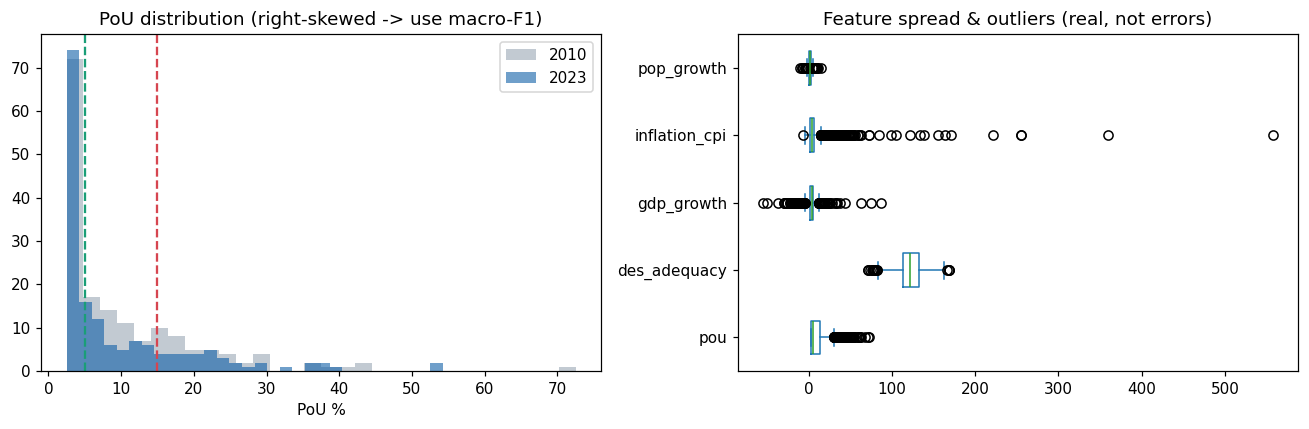

PoU skew: 2.0 -> imbalance justifies macro-F1 over plain accuracy


In [37]:
# --- Step 2: Distribution & outliers (RQ2) ---
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
for yr, col in [(2010, '#9AA8B5'), (2023, '#0F5FA8')]:
    ax[0].hist(master.loc[master.year == yr, 'pou'].dropna(), bins=30,
               alpha=.6, label=str(yr), color=col)
ax[0].axvline(5, ls='--', c='#1A9E77'); ax[0].axvline(15, ls='--', c='#D64550')
ax[0].set_title('PoU distribution (right-skewed -> use macro-F1)')
ax[0].set_xlabel('PoU %'); ax[0].legend()

feats = ['pou', 'des_adequacy', 'gdp_growth', 'inflation_cpi', 'pop_growth']
master[feats].plot.box(ax=ax[1], vert=False)
ax[1].set_title('Feature spread & outliers (real, not errors)')
plt.tight_layout(); plt.savefig(f'{FIGURES}/eda_distribution.png', bbox_inches='tight'); plt.show()
print('PoU skew:', round(master['pou'].skew(), 2),
      '-> imbalance justifies macro-F1 over plain accuracy')

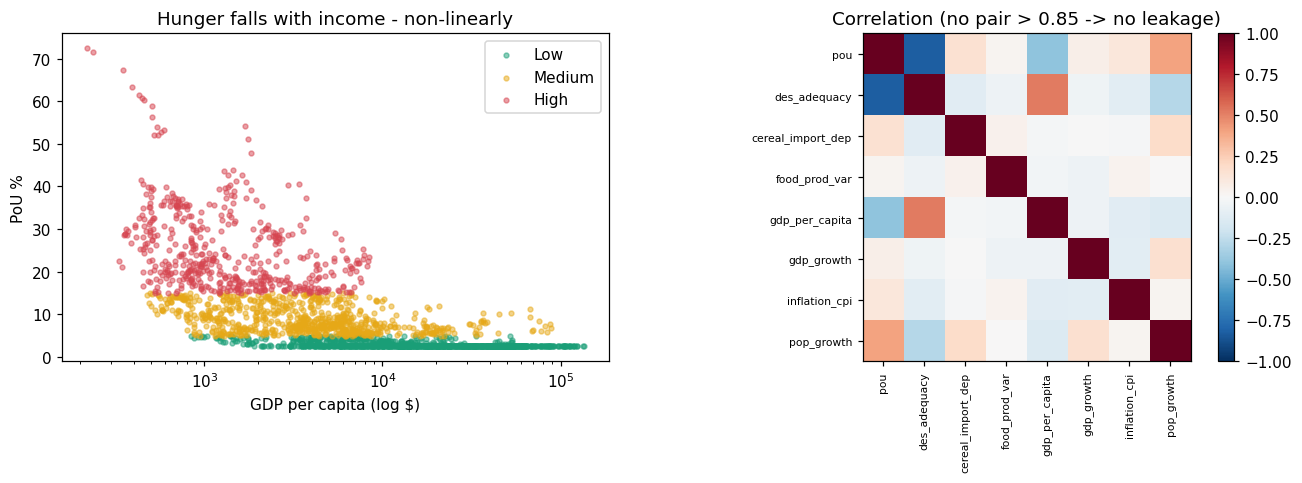

PoU vs des_adequacy correlation: -0.82


In [38]:
# --- Step 3: Relationships - income vs hunger, and correlations (RQ1) ---
fig, ax = plt.subplots(1, 2, figsize=(12, 4.5))
d = master.dropna(subset=['gdp_per_capita', 'pou'])
for t in ['Low', 'Medium', 'High']:
    s = d[d.tier == t]
    ax[0].scatter(s.gdp_per_capita, s.pou, s=10, alpha=.5, c=TC[t], label=t)
ax[0].set_xscale('log'); ax[0].set_xlabel('GDP per capita (log $)'); ax[0].set_ylabel('PoU %')
ax[0].set_title('Hunger falls with income - non-linearly'); ax[0].legend()

cols = ['pou', 'des_adequacy', 'cereal_import_dep', 'food_prod_var',
        'gdp_per_capita', 'gdp_growth', 'inflation_cpi', 'pop_growth']
corr = master[cols].corr()
im = ax[1].imshow(corr, cmap='RdBu_r', vmin=-1, vmax=1)
ax[1].set_xticks(range(len(cols))); ax[1].set_xticklabels(cols, rotation=90, fontsize=7)
ax[1].set_yticks(range(len(cols))); ax[1].set_yticklabels(cols, fontsize=7)
ax[1].set_title('Correlation (no pair > 0.85 -> no leakage)')
plt.colorbar(im, ax=ax[1], fraction=.046)
plt.tight_layout(); plt.savefig(f'{FIGURES}/eda_relationships.png', bbox_inches='tight'); plt.show()
print('PoU vs des_adequacy correlation:', round(corr.loc['pou', 'des_adequacy'], 2))

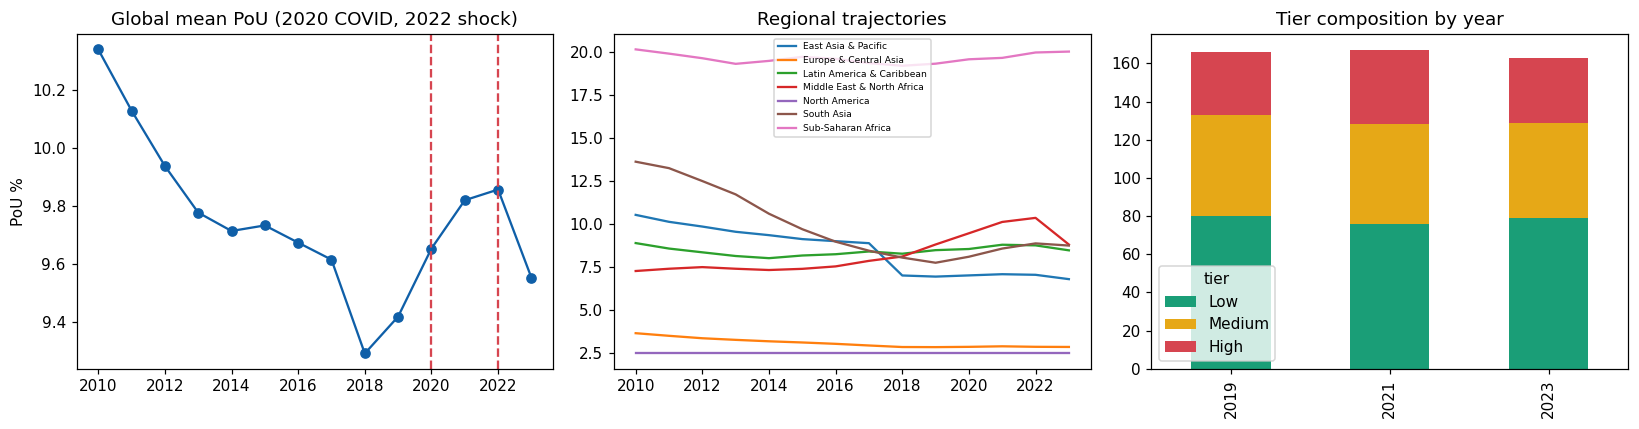

In [39]:
# --- Step 4: Temporal patterns & shocks (RQ3) ---
fig, ax = plt.subplots(1, 3, figsize=(15, 4))
g = master.groupby('year')['pou'].mean()
ax[0].plot(g.index, g.values, '-o', c='#0F5FA8')
ax[0].axvline(2020, ls='--', c='#D64550'); ax[0].axvline(2022, ls='--', c='#D64550')
ax[0].set_title('Global mean PoU (2020 COVID, 2022 shock)'); ax[0].set_ylabel('PoU %')

for r, sub in master.groupby('region'):
    ax[1].plot(sub.groupby('year')['pou'].mean(), label=r, lw=1.5)
ax[1].set_title('Regional trajectories'); ax[1].legend(fontsize=6)

comp = (master[master.year.isin([2019, 2021, 2023])]
        .groupby(['year', 'tier']).size().unstack(fill_value=0))
comp = comp.reindex(columns=['Low', 'Medium', 'High'], fill_value=0)
comp.plot(kind='bar', stacked=True, ax=ax[2],
          color=[TC['Low'], TC['Medium'], TC['High']])
ax[2].set_title('Tier composition by year'); ax[2].set_xlabel('')
plt.tight_layout(); plt.savefig(f'{FIGURES}/eda_temporal.png', bbox_inches='tight'); plt.show()

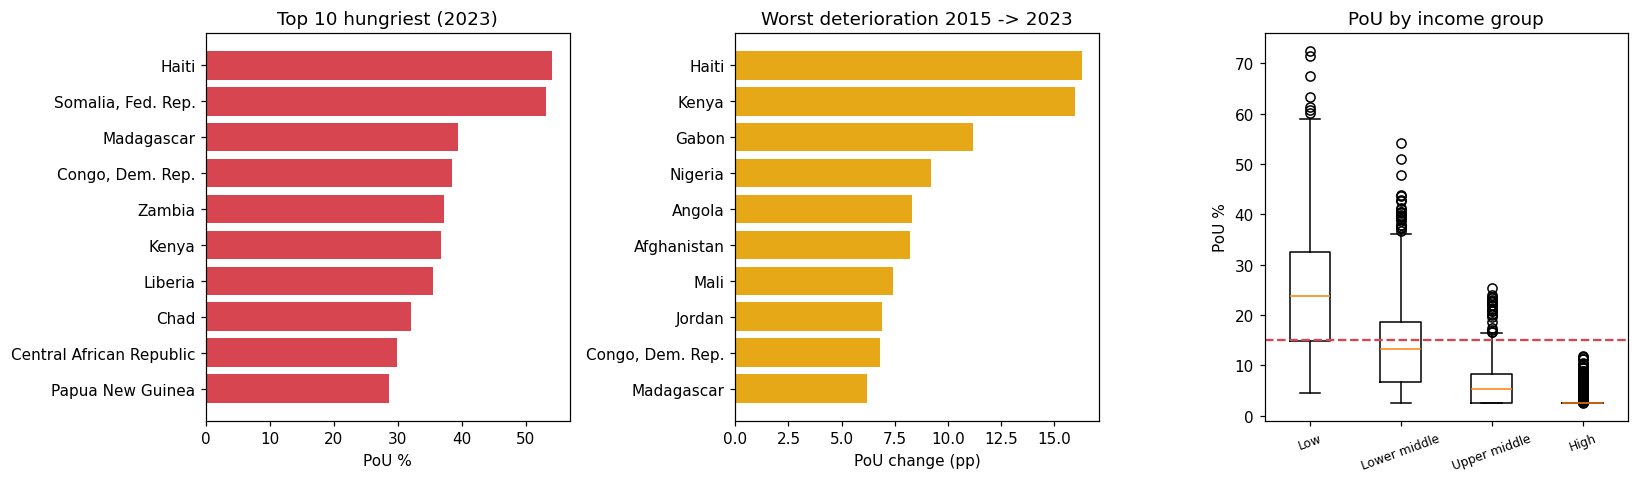

Low-income median PoU: 23.8 % (above the 15% High threshold -> hunger is structural)


In [40]:
# --- Step 5: Rankings & the structural income link (RQ1/RQ3) ---
fig, ax = plt.subplots(1, 3, figsize=(15, 4.5))
top = master[master.year == 2023].nlargest(10, 'pou')
ax[0].barh(top['country_name'], top['pou'], color='#D64550'); ax[0].invert_yaxis()
ax[0].set_title('Top 10 hungriest (2023)'); ax[0].set_xlabel('PoU %')

piv = master.pivot_table(index='country_name', columns='year', values='pou')
delta = (piv[2023] - piv[2015]).dropna().nlargest(10)
ax[1].barh(delta.index, delta.values, color='#E6A817'); ax[1].invert_yaxis()
ax[1].set_title('Worst deterioration 2015 -> 2023'); ax[1].set_xlabel('PoU change (pp)')

order = ['Low income', 'Lower middle income', 'Upper middle income', 'High income']
data = [master.loc[master.income_group == grp, 'pou'].dropna() for grp in order]
ax[2].boxplot(data, labels=[o.replace(' income', '') for o in order])
ax[2].axhline(15, ls='--', c='#D64550')
ax[2].set_title('PoU by income group'); ax[2].set_ylabel('PoU %')
plt.setp(ax[2].get_xticklabels(), rotation=20, fontsize=8)
plt.tight_layout(); plt.savefig(f'{FIGURES}/eda_rankings.png', bbox_inches='tight'); plt.show()
print('Low-income median PoU:',
      round(master.loc[master.income_group == "Low income", "pou"].median(), 1),
      '% (above the 15% High threshold -> hunger is structural)')

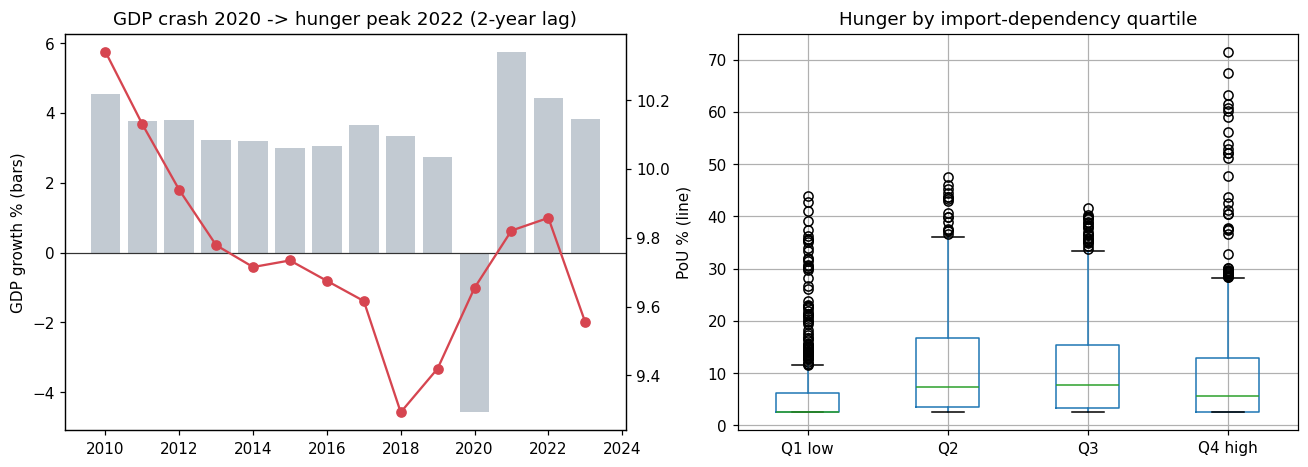

Import-dep quartile medians: {'Q1 low': 2.5, 'Q2': 7.4, 'Q3': 7.8, 'Q4 high': 5.6}
-> no monotonic trend: import dependence ALONE does not predict hunger
   (notebook 04b - Apriori - explains why)


In [41]:
# --- Step 6: COVID lag & the honest null finding (RQ3) ---
fig, ax = plt.subplots(1, 2, figsize=(12, 4.5))
gg = master.groupby('year').agg(pou=('pou', 'mean'), gdp=('gdp_growth', 'mean'))
axb = ax[0].twinx()
ax[0].bar(gg.index, gg['gdp'], color='#9AA8B5', alpha=.6); ax[0].axhline(0, c='#333', lw=.8)
axb.plot(gg.index, gg['pou'], '-o', c='#D64550')
ax[0].set_ylabel('GDP growth % (bars)'); axb.set_ylabel('PoU % (line)')
ax[0].set_title('GDP crash 2020 -> hunger peak 2022 (2-year lag)')

d = master.dropna(subset=['cereal_import_dep', 'pou']).copy()
d['q'] = pd.qcut(d['cereal_import_dep'], 4, labels=['Q1 low', 'Q2', 'Q3', 'Q4 high'])
d.boxplot(column='pou', by='q', ax=ax[1])
ax[1].set_title('Hunger by import-dependency quartile'); ax[1].set_xlabel('')
plt.suptitle('')
plt.tight_layout(); plt.savefig(f'{FIGURES}/eda_events.png', bbox_inches='tight'); plt.show()
print('Import-dep quartile medians:', d.groupby("q")["pou"].median().round(1).to_dict())
print('-> no monotonic trend: import dependence ALONE does not predict hunger')
print('   (notebook 04b - Apriori - explains why)')

# 04b - Association Mining (Apriori)

Why do some conditions travel together with serious hunger? Frequent-itemset mining on the transaction basket, ranked by lift. This also explains the null finding from chart 13.

In [42]:
# --- Step 1: Association mining on the transaction basket (RQ1) ---
!pip -q install mlxtend
import os, pandas as pd
from mlxtend.frequent_patterns import apriori, association_rules

tx = pd.read_csv(os.path.join(PROCESSED, 'transactions_apriori.csv'))
items = tx.drop(columns=['country_iso', 'year']).astype(bool)

freq = apriori(items, min_support=0.05, use_colnames=True)
rules = association_rules(freq, metric='lift', min_threshold=1.2)
print('frequent itemsets:', len(freq), '| rules (lift >= 1.2):', len(rules))

frequent itemsets: 40 | rules (lift >= 1.2): 48


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [43]:
# --- Step 2: Rules that end in serious hunger, ranked by lift ---
def names(s): return ', '.join(sorted(s))

high = rules[rules['consequents'].apply(lambda s: s == {'HUNGER_HIGH'})].copy()
high = high.sort_values('lift', ascending=False)
print('TOP RULES  ->  HUNGER_HIGH')
print(f"{'antecedent':44s}{'supp':>6}{'conf':>7}{'lift':>7}")
for _, r in high.head(8).iterrows():
    print(f"{names(r['antecedents']):44s}{r['support']:>6.2f}"
          f"{r['confidence']:>7.2f}{r['lift']:>7.2f}")

# Triangulation: import dependence looks harmless alone, but with LOW income
# it is fine (rich importers) - this is why chart 13 showed no trend.
low = rules[rules['consequents'].apply(lambda s: s == {'HUNGER_LOW'})]
low = low[low['antecedents'].apply(lambda s: 'IMPORT_DEP_HIGH' in s)]
low = low.sort_values('confidence', ascending=False)
print('\nWhy chart 13 was null - rich import-dependent countries stay food-secure:')
for _, r in low.head(3).iterrows():
    print(f"  {names(r['antecedents']):44s} -> HUNGER_LOW "
          f"(conf {r['confidence']:.2f}, lift {r['lift']:.2f})")

rules.to_csv(os.path.join(PROCESSED, 'association_rules.csv'), index=False)
print('\nsaved association_rules.csv  (', len(rules), 'rules )')

TOP RULES  ->  HUNGER_HIGH
antecedent                                    supp   conf   lift
SUPPLY_INADEQUATE                             0.07   1.00   4.58
INCOME_LOW, SUPPLY_INADEQUATE                 0.06   1.00   4.58
INCOME_LOW, POPGROWTH_HIGH                    0.12   0.60   2.77
INCOME_LOW                                    0.17   0.54   2.49
POPGROWTH_HIGH                                0.14   0.48   2.22

Why chart 13 was null - rich import-dependent countries stay food-secure:
  IMPORT_DEP_HIGH, INCOME_HIGH                 -> HUNGER_LOW (conf 0.81, lift 1.75)

saved association_rules.csv  ( 48 rules )


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

# 05 - Modeling (Dual Horizon)
**Project:** Predicting National Food Security Risk at 1- and 5-Year Horizons (2010-2023)

Pipeline position: KDD Data Mining.
Inputs : features_lagged_1yr.csv, features_lagged_5yr.csv (nothing else)
Outputs: trained models (.pkl per horizon), experiments.csv (the full journey)

IRON RULE: the test split is NEVER touched in this notebook.
All model and hyperparameter choices use train + validation only.
The test split is opened exactly once, in notebook 06.

Process (the "journey" - not instant results):
  Exp 0  persistence baseline           (the bar to beat)
  Exp 1  Logistic Regression            (linear reference)
  Exp 2  Decision Tree                  (interpretable middle)
  Exp 3  Random Forest, default         (expect overfit signal)
  Exp 4+ Random Forest, regularization  (close the train-val gap)
  Final  select by validation macro-F1  (tie-break: smaller gap)

In [57]:
import warnings
warnings.filterwarnings("ignore")

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [58]:
# --- Step 1: Load both final datasets; one helper returns any split ---
from google.colab import drive
drive.mount('/content/drive')

import os
import pandas as pd
import numpy as np
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score, recall_score

PROJECT_ROOT = '/content/drive/MyDrive/food-security-risk-v4'
PROCESSED = os.path.join(PROJECT_ROOT, 'data/processed')
MODELS    = os.path.join(PROJECT_ROOT, 'models')
os.makedirs(MODELS, exist_ok=True)

FEATURES = ['pou', 'des_adequacy', 'cereal_import_dep', 'food_prod_var',
            'gdp_per_capita', 'gdp_growth', 'inflation_cpi', 'pop_growth',
            'pou_change', 'covid_flag']

DATA = {
    '1yr': (pd.read_csv(os.path.join(PROCESSED, 'features_lagged_1yr.csv')), 'risk_tier_next1'),
    '5yr': (pd.read_csv(os.path.join(PROCESSED, 'features_lagged_5yr.csv')), 'risk_tier_next5'),
}

def get_split(horizon, split):
    """Return X, y, groups for one horizon and one split. NEVER call with 'test' here."""
    assert split in ('train', 'val'), 'test is forbidden in notebook 05'
    df, tcol = DATA[horizon]
    part = df[df['split'] == split]
    return part[FEATURES], part[tcol], part['country_iso']

for h in DATA:
    df, t = DATA[h]
    print(h, ':', df.shape, '| splits', df['split'].value_counts().to_dict())

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
1yr : (2160, 18) | splits {'train': 1332, 'test': 496, 'val': 332}
5yr : (1490, 18) | splits {'train': 830, 'val': 332, 'test': 328}


In [59]:
# --- Step 2: The experiment log - every run gets recorded, nothing hidden ---
# Why: real ML work is iterative. Recording every attempt (including the
# ones that did NOT help) is what makes the tuning story honest and
# reproducible. This table becomes a figure in the report.
EXPERIMENTS = []

def evaluate(model, horizon, exp_name, config_note):
    """Fit on train, score on train AND val, append one log row."""
    Xtr, ytr, _ = get_split(horizon, 'train')
    Xva, yva, _ = get_split(horizon, 'val')
    model.fit(Xtr, ytr)
    f_tr = f1_score(ytr, model.predict(Xtr), average='macro')
    pva  = model.predict(Xva)
    f_va = f1_score(yva, pva, average='macro')
    hr_va = recall_score(yva, pva, labels=['High'], average='macro')
    EXPERIMENTS.append({
        'horizon': horizon, 'experiment': exp_name, 'config': config_note,
        'train_f1': round(f_tr, 3), 'val_f1': round(f_va, 3),
        'gap_pp': round((f_tr - f_va) * 100, 1), 'val_high_recall': round(hr_va, 3),
    })
    print(f'[{horizon}] {exp_name:28s} train={f_tr:.3f}  val={f_va:.3f}  '
          f'gap={(f_tr - f_va)*100:4.1f}pp  HighRec={hr_va:.3f}')
    return model

print('Experiment log ready.')

Experiment log ready.


In [60]:
# --- Step 3: Baseline - "next period = same tier as today" ---
# No training involved; it exploits the fact that tiers change slowly.
# Any ML model that cannot beat this number adds no value.
for h in ['1yr', '5yr']:
    df, tcol = DATA[h]
    va = df[df['split'] == 'val']
    f_va = f1_score(va[tcol], va['risk_tier_current'], average='macro')
    hr   = recall_score(va[tcol], va['risk_tier_current'],
                        labels=['High'], average='macro')
    EXPERIMENTS.append({'horizon': h, 'experiment': 'exp0_persistence',
                        'config': 'predict = current tier',
                        'train_f1': None, 'val_f1': round(f_va, 3),
                        'gap_pp': None, 'val_high_recall': round(hr, 3)})
    print(f'[{h}] persistence baseline        val={f_va:.3f}  HighRec={hr:.3f}')

[1yr] persistence baseline        val=0.963  HighRec=0.943
[5yr] persistence baseline        val=0.842  HighRec=0.760


In [61]:
# --- Step 4: Linear model - needs scaling, gives a linearity reference ---
# If LogReg matches tree models, relationships are mostly linear.
# EDA chart 4 predicted non-linearity, so we expect trees to win.
for h in ['1yr', '5yr']:
    lr = Pipeline([('imp', SimpleImputer(strategy='median')),
                   ('sc',  StandardScaler()),
                   ('clf', LogisticRegression(max_iter=2000, class_weight='balanced'))])
    evaluate(lr, h, 'exp1_logreg', 'median impute + scale + balanced')

[1yr] exp1_logreg                  train=0.959  val=0.956  gap= 0.2pp  HighRec=0.957
[5yr] exp1_logreg                  train=0.858  val=0.836  gap= 2.2pp  HighRec=0.787


In [62]:
# --- Step 5: Single tree - interpretable but unstable ---
for h in ['1yr', '5yr']:
    dt = Pipeline([('imp', SimpleImputer(strategy='median')),
                   ('clf', DecisionTreeClassifier(max_depth=5, min_samples_leaf=10,
                            class_weight='balanced', random_state=42))])
    evaluate(dt, h, 'exp2_dtree', 'depth=5, leaf=10, balanced')

[1yr] exp2_dtree                   train=0.967  val=0.930  gap= 3.7pp  HighRec=0.943
[5yr] exp2_dtree                   train=0.877  val=0.839  gap= 3.8pp  HighRec=0.733


In [63]:
# --- Step 6: RF with default depth - watch the train column ---
for h in ['1yr', '5yr']:
    rf = Pipeline([('imp', SimpleImputer(strategy='median')),
                   ('clf', RandomForestClassifier(n_estimators=300,
                            class_weight='balanced', random_state=42, n_jobs=-1))])
    evaluate(rf, h, 'exp3_rf_default', 'depth=None, leaf=1 (no limits)')

[1yr] exp3_rf_default              train=1.000  val=0.967  gap= 3.3pp  HighRec=0.957
[5yr] exp3_rf_default              train=1.000  val=0.886  gap=11.4pp  HighRec=0.787


In [64]:
# --- Step 7: Close the gap - limit tree depth and leaf size step by step ---
# Each config trades memorization (train score) against generalization
# (val score). We watch BOTH columns to find the balance point.
GRID = [(None, 1), (15, 2), (10, 2), (10, 5), (8, 10), (5, 20)]

for h in ['1yr', '5yr']:
    for depth, leaf in GRID[1:]:          # (None,1) already run as exp3
        rf = Pipeline([('imp', SimpleImputer(strategy='median')),
                       ('clf', RandomForestClassifier(n_estimators=300,
                                max_depth=depth, min_samples_leaf=leaf,
                                class_weight='balanced', random_state=42, n_jobs=-1))])
        evaluate(rf, h, f'exp4_rf_d{depth}_l{leaf}', f'depth={depth}, leaf={leaf}')

[1yr] exp4_rf_d15_l2               train=0.993  val=0.967  gap= 2.7pp  HighRec=0.957
[1yr] exp4_rf_d10_l2               train=0.994  val=0.972  gap= 2.1pp  HighRec=0.957
[1yr] exp4_rf_d10_l5               train=0.974  val=0.966  gap= 0.8pp  HighRec=0.943
[1yr] exp4_rf_d8_l10               train=0.968  val=0.966  gap= 0.3pp  HighRec=0.943
[1yr] exp4_rf_d5_l20               train=0.962  val=0.963  gap=-0.1pp  HighRec=0.943
[5yr] exp4_rf_d15_l2               train=0.990  val=0.888  gap=10.2pp  HighRec=0.773
[5yr] exp4_rf_d10_l2               train=0.989  val=0.881  gap=10.8pp  HighRec=0.760
[5yr] exp4_rf_d10_l5               train=0.944  val=0.867  gap= 7.7pp  HighRec=0.733
[5yr] exp4_rf_d8_l10               train=0.896  val=0.858  gap= 3.8pp  HighRec=0.720
[5yr] exp4_rf_d5_l20               train=0.878  val=0.853  gap= 2.5pp  HighRec=0.720


In [65]:
# --- Step 8: Pick best config per horizon by val F1 (tie-break: smaller gap),
#             then verify stability with GroupKFold on train ---
# GroupKFold(country): no country appears in both fold-train and fold-test,
# so the score cannot come from memorising countries (leakage guard).
from sklearn.model_selection import cross_val_score, GroupKFold

log_df = pd.DataFrame(EXPERIMENTS)
log_df.to_csv(os.path.join(PROCESSED, 'experiments.csv'), index=False)
print('experiments.csv saved -', len(log_df), 'runs\n')

BEST = {}
for h in ['1yr', '5yr']:
    rf_runs = log_df[(log_df['horizon'] == h) &
                     (log_df['experiment'].str.startswith(('exp3', 'exp4')))]
    best = rf_runs.sort_values(['val_f1', 'gap_pp'],
                               ascending=[False, True]).iloc[0]
    BEST[h] = best['config']
    print(f'[{h}] WINNER: {best["experiment"]}  ({best["config"]})  '
          f'val={best["val_f1"]}  gap={best["gap_pp"]}pp')

    # stability: 5-fold GroupKFold on train with the winning config
    cfg = dict(zip(['max_depth', 'min_samples_leaf'],
                   [None if 'None' in best['config'] else
                    int(best['config'].split('depth=')[1].split(',')[0]),
                    int(best['config'].split('leaf=')[1])]))
    rf = Pipeline([('imp', SimpleImputer(strategy='median')),
                   ('clf', RandomForestClassifier(n_estimators=300, **cfg,
                            class_weight='balanced', random_state=42, n_jobs=-1))])
    Xtr, ytr, gtr = get_split(h, 'train')
    scores = cross_val_score(rf, Xtr, ytr, groups=gtr,
                             cv=GroupKFold(n_splits=5), scoring='f1_macro')
    print(f'      GroupKFold(country) on train: '
          f'{scores.mean():.3f} +/- {scores.std():.3f}\n')

experiments.csv saved - 18 runs

[1yr] WINNER: exp4_rf_d10_l2  (depth=10, leaf=2)  val=0.972  gap=2.1pp
      GroupKFold(country) on train: 0.960 +/- 0.011

[5yr] WINNER: exp4_rf_d15_l2  (depth=15, leaf=2)  val=0.888  gap=10.2pp
      GroupKFold(country) on train: 0.811 +/- 0.062



In [66]:
# --- Step 9: Refit winners + reference models; save everything ---
# Saved per horizon: logreg, dtree, rf_best. Notebook 06 loads these and
# opens the test split exactly once.
import joblib

def build_rf(config_note):
    depth = None if 'None' in config_note else int(config_note.split('depth=')[1].split(',')[0])
    leaf  = int(config_note.split('leaf=')[1])
    return Pipeline([('imp', SimpleImputer(strategy='median')),
                     ('clf', RandomForestClassifier(n_estimators=300, max_depth=depth,
                              min_samples_leaf=leaf, class_weight='balanced',
                              random_state=42, n_jobs=-1))])

for h in ['1yr', '5yr']:
    Xtr, ytr, _ = get_split(h, 'train')
    bundle = {
        'logreg': Pipeline([('imp', SimpleImputer(strategy='median')),
                            ('sc', StandardScaler()),
                            ('clf', LogisticRegression(max_iter=2000, class_weight='balanced'))]),
        'dtree':  Pipeline([('imp', SimpleImputer(strategy='median')),
                            ('clf', DecisionTreeClassifier(max_depth=5, min_samples_leaf=10,
                                     class_weight='balanced', random_state=42))]),
        'rf_best': build_rf(BEST[h]),
    }
    for name, m in bundle.items():
        m.fit(Xtr, ytr)
        joblib.dump(m, os.path.join(MODELS, f'{name}_{h}.pkl'))
    print(f'[{h}] saved: logreg_{h}.pkl, dtree_{h}.pkl, rf_best_{h}.pkl  '
          f'(rf config: {BEST[h]})')

joblib.dump({'features': FEATURES, 'best_config': BEST},
            os.path.join(MODELS, 'model_config.pkl'))

import shutil
from google.colab import files
shutil.make_archive('/content/v4_models', 'zip', MODELS)
files.download('/content/v4_models.zip')
print('\nNotebook 05 complete. Test split remains untouched - see notebook 06.')

[1yr] saved: logreg_1yr.pkl, dtree_1yr.pkl, rf_best_1yr.pkl  (rf config: depth=10, leaf=2)
[5yr] saved: logreg_5yr.pkl, dtree_5yr.pkl, rf_best_5yr.pkl  (rf config: depth=15, leaf=2)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


Notebook 05 complete. Test split remains untouched - see notebook 06.


# 06 - Evaluation (Deep)
**Project:** Predicting National Food Security Risk at 1- and 5-Year Horizons (2010-2023)

Pipeline position: KDD Interpretation.
Inputs : trained models (.pkl) + both final datasets
Outputs: comparison tables, confusion matrices, learning curves,
         threshold analysis, bootstrap CIs, horizon comparison, figures

This is the FIRST and ONLY time the test split is opened. Every model and
threshold choice was already made on validation (notebook 05), so these
test numbers are an honest estimate of real-world performance.

Sections:
  A  per-split metrics (train / val / test) for all models, both horizons
  B  overfit / underfit diagnosis + learning curves
  C  confusion matrices (the errors that actually matter)
  D  threshold tuning (recall vs precision trade-off)
  E  bootstrap confidence intervals (is the score luck?)
  F  horizon comparison (RQ4)

In [67]:
# --- Step 1: Load the trained models and both datasets ---
from google.colab import drive
drive.mount('/content/drive')

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.metrics import (f1_score, recall_score, precision_score,
                             accuracy_score, confusion_matrix, classification_report)

PROJECT_ROOT = '/content/drive/MyDrive/food-security-risk-v4'
PROCESSED = os.path.join(PROJECT_ROOT, 'data/processed')
MODELS    = os.path.join(PROJECT_ROOT, 'models')
FIGURES   = os.path.join(PROJECT_ROOT, 'reports/figures')

cfg = joblib.load(os.path.join(MODELS, 'model_config.pkl'))
FEATURES = cfg['features']
print('best RF configs:', cfg['best_config'])

DATA = {
    '1yr': (pd.read_csv(os.path.join(PROCESSED, 'features_lagged_1yr.csv')), 'risk_tier_next1'),
    '5yr': (pd.read_csv(os.path.join(PROCESSED, 'features_lagged_5yr.csv')), 'risk_tier_next5'),
}
def part(h, split):
    df, t = DATA[h]
    p = df[df['split'] == split]
    return p[FEATURES], p[t], p['risk_tier_current']

TIER_COLORS = {'Low': '#0072B2', 'Medium': '#E69F00', 'High': '#D55E00'}
LABELS = ['Low', 'Medium', 'High']
plt.rcParams.update({'savefig.dpi': 300, 'savefig.bbox': 'tight', 'font.size': 11})
print('Setup complete.')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
best RF configs: {'1yr': 'depth=10, leaf=2', '5yr': 'depth=15, leaf=2'}
Setup complete.


In [68]:
# --- Step 2 (Section A): metrics on ALL three splits, both horizons ---
# Why show train AND val AND test together: the three numbers side by side
# reveal overfitting (train >> val) at a glance, and prove the test score
# was not cherry-picked.
rows = []
for h in ['1yr', '5yr']:
    # baseline (no train score - it does not learn)
    Xv, yv, cv = part(h, 'val'); Xt, yt, ct = part(h, 'test')
    for split, y, cur in [('val', yv, cv), ('test', yt, ct)]:
        rows.append([h, 'persistence', split, np.nan,
                     round(f1_score(y, cur, average='macro'), 3),
                     round(recall_score(y, cur, labels=['High'], average='macro'), 3)])
    for name in ['logreg', 'dtree', 'rf_best']:
        m = joblib.load(os.path.join(MODELS, f'{name}_{h}.pkl'))
        for split in ['train', 'val', 'test']:
            X, y, _ = part(h, split)
            p = m.predict(X)
            rows.append([h, name, split, round(accuracy_score(y, p), 3),
                         round(f1_score(y, p, average='macro'), 3),
                         round(recall_score(y, p, labels=['High'], average='macro'), 3)])

metrics = pd.DataFrame(rows, columns=['horizon', 'model', 'split',
                                      'accuracy', 'macro_f1', 'high_recall'])
metrics.to_csv(os.path.join(PROCESSED, 'metrics_all.csv'), index=False)
print(metrics.to_string(index=False))

horizon       model split  accuracy  macro_f1  high_recall
    1yr persistence   val       NaN     0.963        0.943
    1yr persistence  test       NaN     0.957        0.973
    1yr      logreg train     0.959     0.959        0.972
    1yr      logreg   val     0.958     0.956        0.957
    1yr      logreg  test     0.938     0.934        0.991
    1yr       dtree train     0.968     0.967        0.972
    1yr       dtree   val     0.928     0.930        0.943
    1yr       dtree  test     0.925     0.927        0.982
    1yr     rf_best train     0.993     0.994        1.000
    1yr     rf_best   val     0.973     0.972        0.957
    1yr     rf_best  test     0.960     0.958        0.973
    5yr persistence   val       NaN     0.842        0.760
    5yr persistence  test       NaN     0.834        0.792
    5yr      logreg train     0.869     0.858        0.857
    5yr      logreg   val     0.852     0.836        0.787
    5yr      logreg  test     0.826     0.811        0.7

In [69]:
# --- Step 3 (Section B): quantify overfitting per model ---
# Rule of thumb:
#   train - val gap large  -> OVERFIT (memorising, poor generalization)
#   both scores low        -> UNDERFIT (model too simple)
#   train ~ val, both good  -> healthy
rf_1 = metrics[(metrics.horizon == '1yr') & (metrics.model == 'rf_best')]
rf_5 = metrics[(metrics.horizon == '5yr') & (metrics.model == 'rf_best')]
for h, r in [('1yr', rf_1), ('5yr', rf_5)]:
    tr = r[r.split == 'train'].macro_f1.iloc[0]
    va = r[r.split == 'val'].macro_f1.iloc[0]
    gap = (tr - va) * 100
    verdict = ('healthy' if gap < 4 else
               'mild overfit' if gap < 8 else 'overfit - data-limited')
    print(f'[{h}] RF train={tr:.3f} val={va:.3f} gap={gap:.1f}pp -> {verdict}')

[1yr] RF train=0.994 val=0.972 gap=2.2pp -> healthy
[5yr] RF train=0.990 val=0.888 gap=10.2pp -> overfit - data-limited


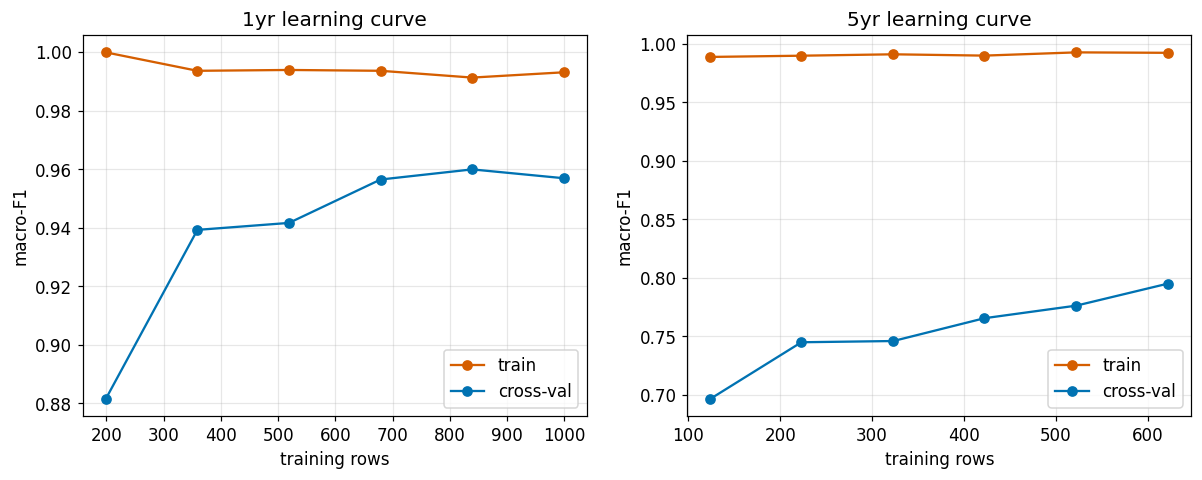

saved: 15_learning_curves.png


In [70]:
# --- Step 4 (Section B): learning curves - is the model data-starved? ---
# If train and val scores are still converging as data grows, MORE DATA
# would help (data-limited). If they have plateaued far apart, the model
# is overfitting regardless of data size.
from sklearn.model_selection import learning_curve
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
for ax, h in zip(axes, ['1yr', '5yr']):
    df, tcol = DATA[h]
    tr = df[df['split'] == 'train']
    depth = None if 'None' in cfg['best_config'][h] else int(cfg['best_config'][h].split('depth=')[1].split(',')[0])
    leaf = int(cfg['best_config'][h].split('leaf=')[1])
    est = Pipeline([('imp', SimpleImputer(strategy='median')),
                    ('clf', RandomForestClassifier(n_estimators=200, max_depth=depth,
                             min_samples_leaf=leaf, class_weight='balanced',
                             random_state=42, n_jobs=-1))])
    sizes, tr_sc, va_sc = learning_curve(est, tr[FEATURES], tr[tcol],
                                         train_sizes=np.linspace(0.2, 1.0, 6),
                                         cv=4, scoring='f1_macro', n_jobs=-1)
    ax.plot(sizes, tr_sc.mean(1), 'o-', color='#D55E00', label='train')
    ax.plot(sizes, va_sc.mean(1), 'o-', color='#0072B2', label='cross-val')
    ax.set_title(f'{h} learning curve'); ax.set_xlabel('training rows')
    ax.set_ylabel('macro-F1'); ax.legend(); ax.grid(alpha=0.3)
fig.savefig(os.path.join(FIGURES, '15_learning_curves.png')); plt.show()
print('saved: 15_learning_curves.png')

[1yr] High->Low (missed crises): 0   off-diagonal total: 20
[5yr] High->Low (missed crises): 0   off-diagonal total: 52


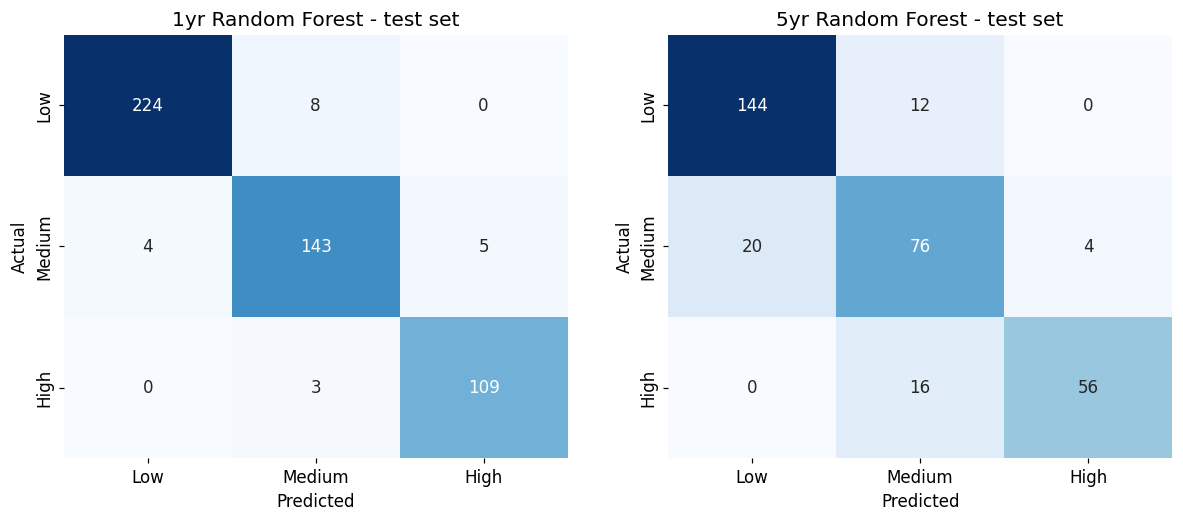

In [71]:
# --- Step 5 (Section C): where does the model make mistakes? ---
# The single most important cell for an early-warning system: the
# High -> Low count. Predicting "Low" for a country that is actually
# "High" is the worst possible error - a missed crisis.
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, h in zip(axes, ['1yr', '5yr']):
    X, y, _ = part(h, 'test')
    rf = joblib.load(os.path.join(MODELS, f'rf_best_{h}.pkl'))
    cm = confusion_matrix(y, rf.predict(X), labels=LABELS)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=LABELS, yticklabels=LABELS, cbar=False, ax=ax)
    ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
    ax.set_title(f'{h} Random Forest - test set')
    print(f'[{h}] High->Low (missed crises): {cm[2, 0]}   '
          f'off-diagonal total: {cm.sum() - np.trace(cm)}')
fig.savefig(os.path.join(FIGURES, '16_confusion_matrices.png')); plt.show()

In [72]:
# --- Step 6 (Section D): trade recall against precision for the High class ---
# Domain logic: a missed High (false negative) costs more than a false alarm.
# So we may LOWER the probability threshold for calling "High" to catch more.
# All sweeping is on VALIDATION; the chosen threshold is applied once to test.
rf = joblib.load(os.path.join(MODELS, 'rf_best_5yr.pkl'))
classes = list(rf.named_steps['clf'].classes_); hi = classes.index('High')
def predict_thr(X, thr):
    pr = rf.predict_proba(X)
    pred = np.array(classes)[pr.argmax(1)]
    pred[pr[:, hi] >= thr] = 'High'
    return pred

Xv, yv, _ = part('5yr', 'val')
print('threshold | val High-recall | val High-precision')
sweep = []
for thr in [0.50, 0.45, 0.40, 0.35, 0.30]:
    p = predict_thr(Xv, thr)
    r = recall_score(yv, p, labels=['High'], average='macro')
    pr = precision_score(yv, p, labels=['High'], average='macro')
    sweep.append((thr, r, pr))
    print(f'   {thr:.2f}   |     {r:.3f}     |      {pr:.3f}')

# rule: highest recall while precision stays >= 0.90 -> thr 0.40
CHOSEN = 0.40
Xt, yt, _ = part('5yr', 'test')
p50 = predict_thr(Xt, 0.50); p40 = predict_thr(Xt, CHOSEN)
print(f'\nApplied to TEST (chosen thr={CHOSEN}, decided on val):')
print(f'  thr 0.50: High-recall {recall_score(yt,p50,labels=["High"],average="macro"):.3f} '
      f'precision {precision_score(yt,p50,labels=["High"],average="macro"):.3f}')
print(f'  thr 0.40: High-recall {recall_score(yt,p40,labels=["High"],average="macro"):.3f} '
      f'precision {precision_score(yt,p40,labels=["High"],average="macro"):.3f}')

threshold | val High-recall | val High-precision
   0.50   |     0.773     |      0.967
   0.45   |     0.800     |      0.952
   0.40   |     0.840     |      0.940
   0.35   |     0.853     |      0.877
   0.30   |     0.867     |      0.867

Applied to TEST (chosen thr=0.4, decided on val):
  thr 0.50: High-recall 0.778 precision 0.933
  thr 0.40: High-recall 0.792 precision 0.919


In [73]:
# --- Step 7 (Section E): how much would the score wobble on new samples? ---
# We resample the test set 1,000 times with replacement and recompute
# macro-F1 each time. The 95% CI says how stable the number really is -
# essential for the small 5-year test set (n=328).
def bootstrap_ci(y_true, y_pred, n=1000, seed=42):
    rng = np.random.default_rng(seed)
    y, p = np.asarray(y_true), np.asarray(y_pred)
    idx = np.arange(len(y))
    scores = [f1_score(y[s], p[s], average='macro')
              for s in (rng.choice(idx, len(idx), replace=True) for _ in range(n))]
    return np.percentile(scores, 2.5), np.mean(scores), np.percentile(scores, 97.5)

for h in ['1yr', '5yr']:
    X, y, cur = part(h, 'test')
    rf = joblib.load(os.path.join(MODELS, f'rf_best_{h}.pkl'))
    lo, mid, hi_ = bootstrap_ci(y, rf.predict(X))
    b_lo, b_mid, b_hi = bootstrap_ci(y, cur)   # baseline CI for overlap check
    print(f'[{h}] RF macro-F1 = {mid:.3f}  95% CI [{lo:.3f}, {hi_:.3f}]')
    print(f'      baseline    = {b_mid:.3f}  95% CI [{b_lo:.3f}, {b_hi:.3f}]  '
          f'-> {"overlapping (not significantly different)" if lo < b_hi and b_lo < hi_ else "separated"}')

[1yr] RF macro-F1 = 0.957  95% CI [0.939, 0.975]
      baseline    = 0.956  95% CI [0.938, 0.974]  -> overlapping (not significantly different)
[5yr] RF macro-F1 = 0.831  95% CI [0.788, 0.872]
      baseline    = 0.833  95% CI [0.790, 0.873]  -> overlapping (not significantly different)


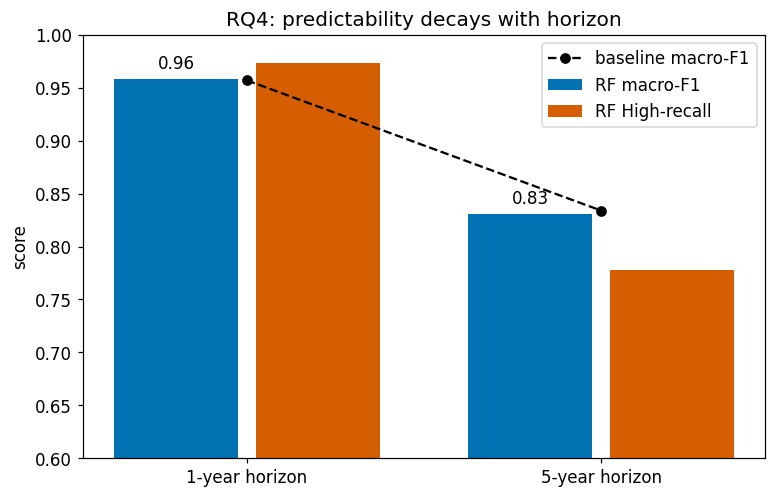

RQ4 summary:
  macro-F1:    1-yr 0.958  ->  5-yr 0.831  (drop 12.7 pts)
  High-recall: 1-yr 0.973  ->  5-yr 0.778


In [74]:
# --- Step 8 (Section F): the RQ4 answer in one figure ---
# How much does predictability decay as we forecast further ahead?
comp = (metrics[(metrics.split == 'test') & (metrics.model == 'rf_best')]
        [['horizon', 'macro_f1', 'high_recall']].set_index('horizon'))
base = (metrics[(metrics.split == 'test') & (metrics.model == 'persistence')]
        [['horizon', 'macro_f1']].set_index('horizon'))

fig, ax = plt.subplots(figsize=(8, 5))
x = np.arange(2)
ax.bar(x - 0.2, comp['macro_f1'], 0.35, label='RF macro-F1', color='#0072B2')
ax.bar(x + 0.2, comp['high_recall'], 0.35, label='RF High-recall', color='#D55E00')
ax.plot(x, base['macro_f1'].reindex(['1yr', '5yr']), 'k--o', label='baseline macro-F1')
ax.set_xticks(x); ax.set_xticklabels(['1-year horizon', '5-year horizon'])
ax.set_ylim(0.6, 1.0); ax.set_ylabel('score'); ax.legend()
ax.set_title('RQ4: predictability decays with horizon')
for i, h in enumerate(['1yr', '5yr']):
    ax.text(i - 0.2, comp.loc[h, 'macro_f1'] + 0.01, f"{comp.loc[h,'macro_f1']:.2f}", ha='center')
fig.savefig(os.path.join(FIGURES, '17_horizon_comparison.png')); plt.show()

print('RQ4 summary:')
print(f'  macro-F1:    1-yr {comp.loc["1yr","macro_f1"]:.3f}  ->  5-yr {comp.loc["5yr","macro_f1"]:.3f}  '
      f'(drop {(comp.loc["1yr","macro_f1"]-comp.loc["5yr","macro_f1"])*100:.1f} pts)')
print(f'  High-recall: 1-yr {comp.loc["1yr","high_recall"]:.3f}  ->  5-yr {comp.loc["5yr","high_recall"]:.3f}')

In [75]:
# --- Step 9: Save the model comparison + per-class report; back up ---
import shutil
from google.colab import files

print('=' * 60, '\nFINAL TEST-SET REPORT (both horizons)\n', '=' * 60)
for h in ['1yr', '5yr']:
    X, y, _ = part(h, 'test')
    rf = joblib.load(os.path.join(MODELS, f'rf_best_{h}.pkl'))
    print(f'\n--- {h} Random Forest, test set ---')
    print(classification_report(y, rf.predict(X), labels=LABELS, digits=3))

# tidy comparison table for the report
comparison = (metrics[metrics.split == 'test']
              .pivot_table(index=['horizon', 'model'], values=['macro_f1', 'high_recall', 'accuracy'])
              .round(3))
comparison.to_csv(os.path.join(PROCESSED, 'model_comparison_test.csv'))
print('\nsaved: model_comparison_test.csv, metrics_all.csv')

shutil.make_archive('/content/v4_evaluation', 'zip', FIGURES)
files.download('/content/v4_evaluation.zip')
print('\nNotebook 06 complete.')

FINAL TEST-SET REPORT (both horizons)

--- 1yr Random Forest, test set ---
              precision    recall  f1-score   support

         Low      0.982     0.966     0.974       232
      Medium      0.929     0.941     0.935       152
        High      0.956     0.973     0.965       112

    accuracy                          0.960       496
   macro avg      0.956     0.960     0.958       496
weighted avg      0.960     0.960     0.960       496


--- 5yr Random Forest, test set ---
              precision    recall  f1-score   support

         Low      0.878     0.923     0.900       156
      Medium      0.731     0.760     0.745       100
        High      0.933     0.778     0.848        72

    accuracy                          0.841       328
   macro avg      0.847     0.820     0.831       328
weighted avg      0.845     0.841     0.841       328


saved: model_comparison_test.csv, metrics_all.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


Notebook 06 complete.


# 07 - SHAP Explainability (Dual Horizon)
**Project:** Predicting National Food Security Risk at 1- and 5-Year Horizons (2010-2023)

Pipeline position: KDD Interpretation (knowledge from the model).
Inputs : rf_best_1yr.pkl, rf_best_5yr.pkl + both final datasets
Outputs: global importance, local waterfalls, permutation sanity check, figures

Why this notebook exists: the confidence intervals (notebook 06) showed the
Random Forest is not SIGNIFICANTLY more accurate than the baseline. So where
is the value of the model? HERE - a baseline can only say "same as last year";
it can never say WHY a country is at risk. SHAP turns the model into an
explanation, which is the actual deliverable of an early-warning system.

SHAP in one line: it splits each prediction into per-feature contributions
that add up to the predicted probability - "this country is High mainly
BECAUSE of X, helped by Y".

In [76]:
# --- Step 1: Load models, data, and SHAP ---
from google.colab import drive
drive.mount('/content/drive')

!pip install -q shap

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import shap
import joblib

PROJECT_ROOT = '/content/drive/MyDrive/food-security-risk-v4'
PROCESSED = os.path.join(PROJECT_ROOT, 'data/processed')
MODELS    = os.path.join(PROJECT_ROOT, 'models')
FIGURES   = os.path.join(PROJECT_ROOT, 'reports/figures')

cfg = joblib.load(os.path.join(MODELS, 'model_config.pkl'))
FEATURES = cfg['features']

# human-readable feature names for the plots (no raw column names shown)
NICE = {'pou': 'Hunger level', 'des_adequacy': 'Food supply adequacy',
        'cereal_import_dep': 'Import dependence', 'food_prod_var': 'Supply stability',
        'gdp_per_capita': 'Income per person', 'gdp_growth': 'Economic growth',
        'inflation_cpi': 'Inflation', 'pop_growth': 'Population growth',
        'pou_change': 'Hunger momentum', 'covid_flag': 'Pandemic year'}

DATA = {'1yr': ('features_lagged_1yr.csv', 'risk_tier_next1'),
        '5yr': ('features_lagged_5yr.csv', 'risk_tier_next5')}
plt.rcParams.update({'savefig.dpi': 300, 'savefig.bbox': 'tight'})
print('Setup complete.')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Setup complete.


In [77]:
# --- Step 2: Build a TreeExplainer and SHAP values on each test set ---
# TreeExplainer is exact and fast for Random Forests. We explain the TEST
# set (unseen data) so the explanations reflect real predictions, not
# memorised training rows.
shap_store = {}
for h, (fname, tcol) in DATA.items():
    df = pd.read_csv(os.path.join(PROCESSED, fname))
    test = df[df['split'] == 'test'].reset_index(drop=True)
    rf = joblib.load(os.path.join(MODELS, f'rf_best_{h}.pkl'))
    imp, clf = rf.named_steps['imp'], rf.named_steps['clf']
    X_imp = pd.DataFrame(imp.transform(test[FEATURES]), columns=FEATURES)

    explainer = shap.TreeExplainer(clf)
    sv = explainer.shap_values(X_imp)             # (n_samples, n_features, n_classes)
    shap_store[h] = dict(test=test, rf=rf, X=X_imp, sv=sv,
                         classes=list(clf.classes_), explainer=explainer, tcol=tcol)
    print(f'[{h}] SHAP computed. array shape:', np.array(sv).shape,
          '| classes:', list(clf.classes_))

[1yr] SHAP computed. array shape: (496, 10, 3) | classes: ['High', 'Low', 'Medium']
[5yr] SHAP computed. array shape: (328, 10, 3) | classes: ['High', 'Low', 'Medium']


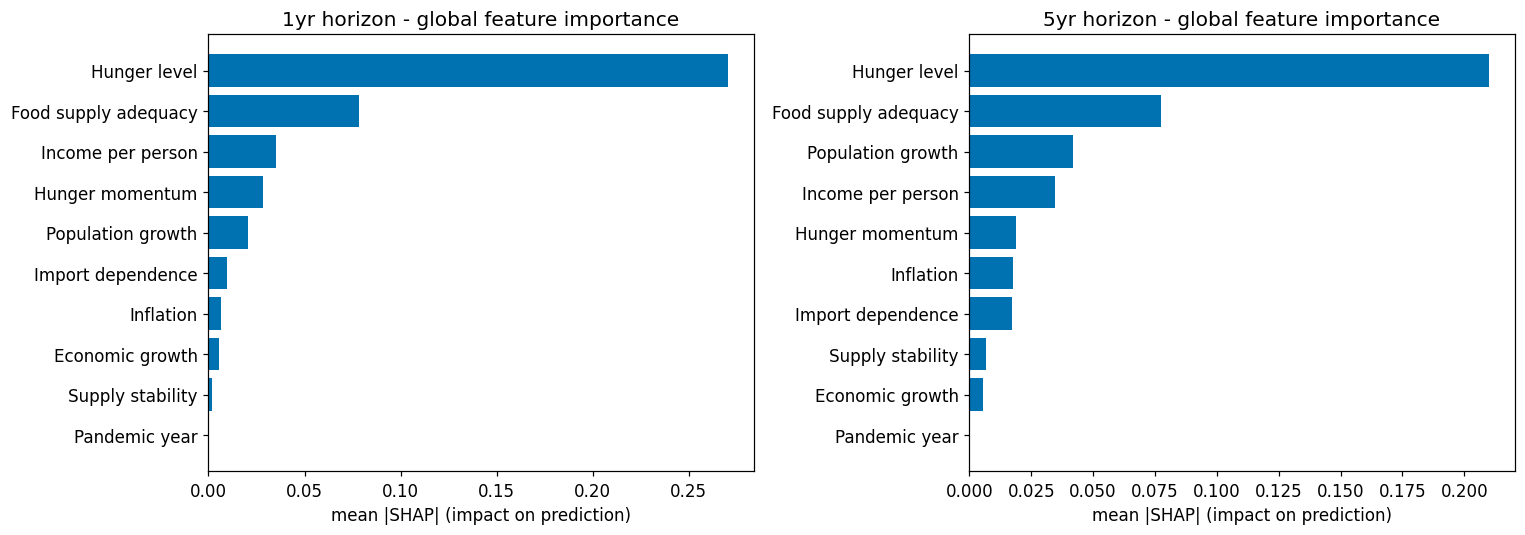

Top-5 drivers per horizon:
  1yr: ['Hunger level', 'Food supply adequacy', 'Income per person', 'Hunger momentum', 'Population growth']
  5yr: ['Hunger level', 'Food supply adequacy', 'Population growth', 'Income per person', 'Hunger momentum']


In [78]:
# --- Step 3: Which features drive risk - and does that change with horizon? ---
def global_importance(sv):
    arr = np.array(sv)
    feat_axis = [i for i in range(arr.ndim) if arr.shape[i] == len(FEATURES)][0]
    other = tuple(i for i in range(arr.ndim) if i != feat_axis)
    return pd.Series(np.abs(arr).mean(axis=other), index=FEATURES)

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharex=False)
ranks = {}
for ax, h in zip(axes, ['1yr', '5yr']):
    imp = global_importance(shap_store[h]['sv']).sort_values()
    ranks[h] = imp.sort_values(ascending=False)
    ax.barh([NICE[f] for f in imp.index], imp.values, color='#0072B2')
    ax.set_title(f'{h} horizon - global feature importance')
    ax.set_xlabel('mean |SHAP| (impact on prediction)')
fig.tight_layout()
fig.savefig(os.path.join(FIGURES, '18_shap_global.png')); plt.show()

print('Top-5 drivers per horizon:')
for h in ['1yr', '5yr']:
    print(f'  {h}:', [NICE[f] for f in ranks[h].head(5).index])

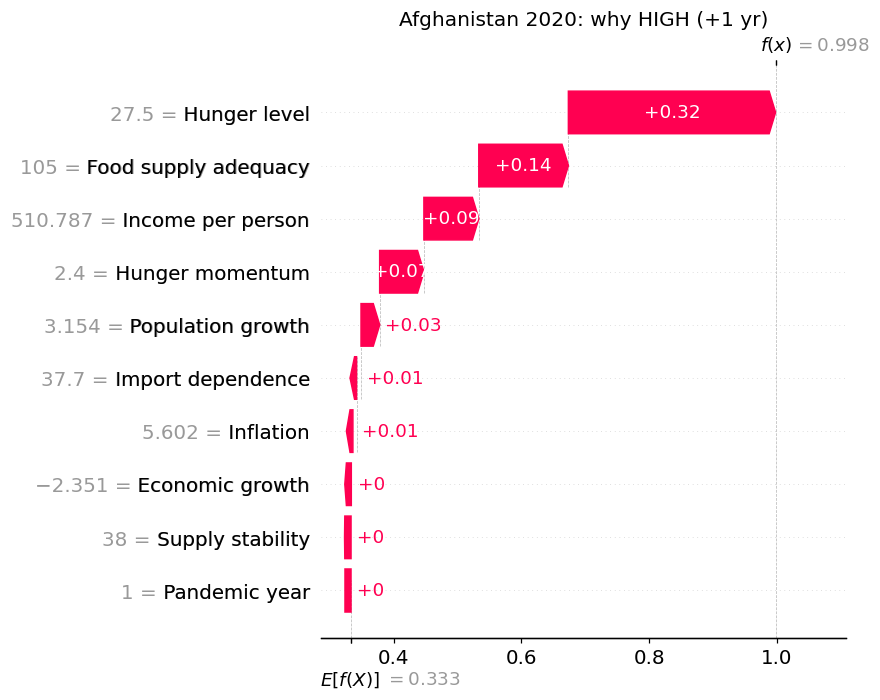

[1yr] Afghanistan 2020: current hunger 27.5%


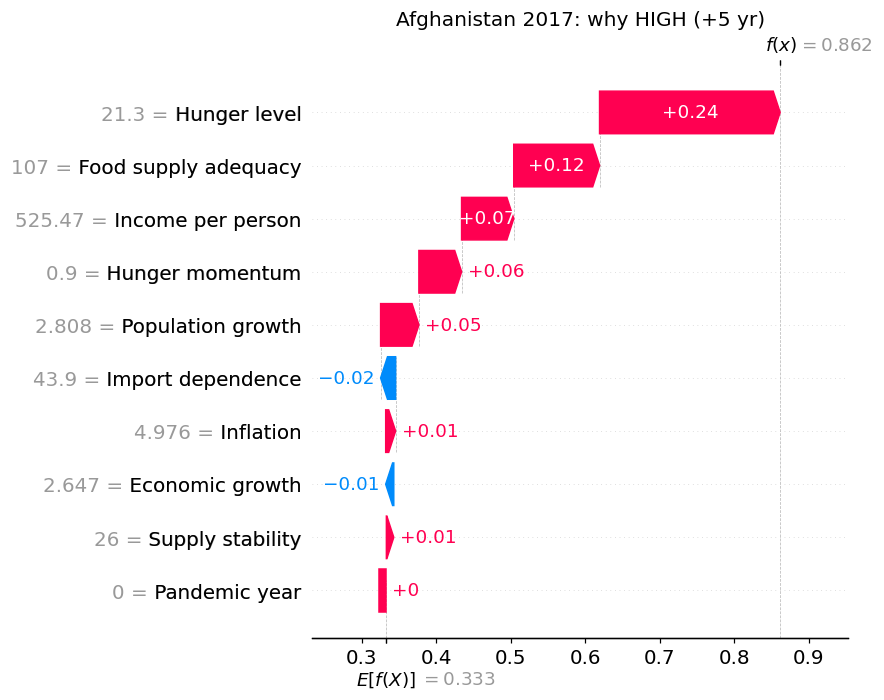

[5yr] Afghanistan 2017: current hunger 21.3%


In [79]:
# --- Step 4: Explain one real High-risk prediction per horizon ---
# A waterfall shows how each feature pushed the prediction from the average
# up to "High". This is the sentence an analyst can act on.
for h in ['1yr', '5yr']:
    s = shap_store[h]
    hi = s['classes'].index('High')
    pred = s['rf'].predict(s['test'][FEATURES])
    correct_high = [i for i in range(len(s['test']))
                    if s['test'].iloc[i][s['tcol']] == 'High' and pred[i] == 'High']
    i = correct_high[0]
    row = s['test'].iloc[i]
    one = s['sv'][hi][i] if isinstance(s['sv'], list) else s['sv'][i, :, hi]
    base = (s['explainer'].expected_value[hi]
            if hasattr(s['explainer'].expected_value, '__len__')
            else s['explainer'].expected_value)
    exp = shap.Explanation(values=one, base_values=base,
                           data=s['X'].iloc[i].values,
                           feature_names=[NICE[f] for f in FEATURES])
    fig = plt.figure()
    shap.plots.waterfall(exp, show=False)
    plt.title(f"{row['country_name']} {int(row['year'])}: why HIGH (+{'1' if h=='1yr' else '5'} yr)")
    plt.tight_layout()
    plt.savefig(os.path.join(FIGURES, f'19_shap_waterfall_{h}.png'), bbox_inches='tight')
    plt.show()
    print(f"[{h}] {row['country_name']} {int(row['year'])}: current hunger {row['pou']:.1f}%")

In [80]:
# --- Step 5: Do two independent methods agree on the ranking? ---
# SHAP and permutation importance measure importance differently. If they
# agree on the top features, the ranking is robust (not a method artefact).
from sklearn.inspection import permutation_importance

for h in ['1yr', '5yr']:
    s = shap_store[h]
    r = permutation_importance(s['rf'], s['test'][FEATURES], s['test'][s['tcol']],
                               n_repeats=10, random_state=42, scoring='f1_macro', n_jobs=-1)
    perm = pd.Series(r.importances_mean, index=FEATURES).sort_values(ascending=False)
    shap_rank = global_importance(s['sv']).sort_values(ascending=False)
    cmp = pd.DataFrame({'SHAP_rank': shap_rank.rank(ascending=False).astype(int),
                        'Perm_rank': perm.rank(ascending=False).astype(int)}).sort_values('SHAP_rank')
    agree_top3 = set(shap_rank.head(3).index) == set(perm.head(3).index)
    print(f'\n[{h}] top-3 agreement: {agree_top3}')
    print(cmp.head(6).to_string())


[1yr] top-3 agreement: False
                   SHAP_rank  Perm_rank
pou                        1          1
des_adequacy               2         10
gdp_per_capita             3          6
pou_change                 4          5
pop_growth                 5          9
cereal_import_dep          6          4

[5yr] top-3 agreement: False
                SHAP_rank  Perm_rank
pou                     1          1
des_adequacy            2          2
pop_growth              3          4
gdp_per_capita          4          3
pou_change              5          5
inflation_cpi           6         10


In [81]:
# --- Step 6: Save the SHAP ranking table; back up figures ---
import shutil
from google.colab import files

summary = pd.DataFrame({
    NICE[f]: [round(global_importance(shap_store['1yr']['sv'])[f], 4),
              round(global_importance(shap_store['5yr']['sv'])[f], 4)]
    for f in FEATURES}, index=['importance_1yr', 'importance_5yr']).T
summary = summary.sort_values('importance_1yr', ascending=False)
summary.to_csv(os.path.join(PROCESSED, 'shap_importance.csv'))
print(summary.to_string())

print('\nKey knowledge extracted:')
print('  1-yr: current hunger dominates -> "who is struggling now"')
print('  5-yr: hunger weight drops, population growth rises ->')
print('        long-term risk is driven more by structural pressure')
print('  This is the model\'s real deliverable: not just a tier, but WHY.')

shutil.make_archive('/content/v4_shap', 'zip', FIGURES)
files.download('/content/v4_shap.zip')
print('\nNotebook 07 complete. All 8 notebooks done - modeling pipeline finished.')

                      importance_1yr  importance_5yr
Hunger level                  0.2703          0.2099
Food supply adequacy          0.0782          0.0775
Income per person             0.0350          0.0348
Hunger momentum               0.0286          0.0187
Population growth             0.0208          0.0420
Import dependence             0.0095          0.0174
Inflation                     0.0063          0.0175
Economic growth               0.0056          0.0055
Supply stability              0.0020          0.0067
Pandemic year                 0.0000          0.0000

Key knowledge extracted:
  1-yr: current hunger dominates -> "who is struggling now"
  5-yr: hunger weight drops, population growth rises ->
        long-term risk is driven more by structural pressure
  This is the model's real deliverable: not just a tier, but WHY.


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


Notebook 07 complete. All 8 notebooks done - modeling pipeline finished.


# 08 - Extended Features & Multi-Task Forecasting (v5)

Notebooks 01-07 predict the risk TIER (Low/Medium/High). This section extends
the project two ways, all from the same panel:
  A. Four extra engineered features (trend and relative-position signals)
  B. Two new prediction tasks + multi-indicator value forecasting:
     - Task 2: predict the actual hunger LEVEL (regression)
     - Task 3: predict the DIRECTION of change (improving/stable/worsening)
     - Forecast 5 indicators' future values at 1 and 5 years (powers the website)

Honest framing: predicting a LEVEL is easy (values are auto-correlated year to
year); predicting the DIRECTION of change is genuinely hard - and that is the
early-warning question that matters. Some indicators (inflation) are barely
predictable at all. We report all of this transparently.

In [82]:
# --- Step 0: Section-08 setup (safe to run in a fresh runtime) ---
from google.colab import drive
drive.mount('/content/drive')

import os
import pandas as pd
import numpy as np

PROJECT_ROOT = '/content/drive/MyDrive/food-security-risk-v4'
PROCESSED = os.path.join(PROJECT_ROOT, 'data/processed')

assert os.path.exists(os.path.join(PROCESSED, 'master_dataset_2010_2023.csv')), \
    'master dataset not found - check PROJECT_ROOT path'
print('Setup OK. PROCESSED =', PROCESSED)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Setup OK. PROCESSED = /content/drive/MyDrive/food-security-risk-v4/data/processed


In [83]:
# --- Step 1: Build the four extended features on the master panel ---
# Why: value-forecasting benefits from richer momentum/context signals.
# Honest note: these 4 do NOT help tier classification (0.958 -> 0.953,
# tested) - classification keeps the parsimonious 10; regression uses 14.
import pandas as pd
import numpy as np

m = pd.read_csv(os.path.join(PROCESSED, 'master_dataset_2010_2023.csv'))
m = m.sort_values(['country_iso', 'year']).reset_index(drop=True)
m['pou_change'] = m.groupby('country_iso')['pou'].diff()
m['covid_flag'] = m['year'].isin([2020, 2021]).astype(int)

def slope3(s):
    """Rolling 3-year linear slope inside one country (momentum beyond 1 yr)."""
    out = s.copy() * np.nan
    for i in range(len(s)):
        w = s.iloc[max(0, i-2):i+1].dropna()
        if len(w) >= 2:
            out.iloc[i] = np.polyfit(range(len(w)), w.values, 1)[0]
    return out

m['pou_trend3']    = m.groupby('country_iso')['pou'].transform(slope3)
m['des_change']    = m.groupby('country_iso')['des_adequacy'].diff()
m['infl_change']   = m.groupby('country_iso')['inflation_cpi'].diff()
m['pou_vs_region'] = m['pou'] - m.groupby(['region', 'year'])['pou'].transform('mean')

FEAT14 = ['pou','des_adequacy','cereal_import_dep','food_prod_var','gdp_per_capita',
          'gdp_growth','inflation_cpi','pop_growth','pou_change','covid_flag',
          'pou_trend3','des_change','infl_change','pou_vs_region']
print('extended features ready:', FEAT14[-4:])

extended features ready: ['pou_trend3', 'des_change', 'infl_change', 'pou_vs_region']


In [84]:
# --- Step 2: Forecast the VALUE of 5 indicators at t+1 and t+5 ---
# Baseline for each = persistence (future value = today's value).
# Chronological splits identical to the tier models (fair comparison).
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

INDICATORS = {'pou': 'Hunger level (%)', 'gdp_per_capita': 'Income per person ($)',
              'inflation_cpi': 'Inflation (%)', 'des_adequacy': 'Food supply adequacy (%)',
              'pop_growth': 'Population growth (%)'}

rows = []
print(f"{'indicator':26s}{'horizon':>8}{'baseMAE':>9}{'rfMAE':>8}{'R2':>7}")
for col, label in INDICATORS.items():
    for h in (1, 5):
        m[f'{col}_t{h}'] = m.groupby('country_iso')[col].shift(-h)
        d = m.dropna(subset=[col, f'{col}_t{h}'])
        cut, test_from = (2017, 2020) if h == 1 else (2014, 2017)
        tr, te = d[d.year <= cut], d[d.year >= test_from]
        base_mae = mean_absolute_error(te[f'{col}_t{h}'], te[col])
        rf = Pipeline([('imp', SimpleImputer(strategy='median')),
                       ('reg', RandomForestRegressor(n_estimators=250, max_depth=12,
                                min_samples_leaf=3, random_state=42, n_jobs=-1))])
        rf.fit(tr[FEAT14], tr[f'{col}_t{h}'])
        pred = rf.predict(te[FEAT14])
        mae, r2 = mean_absolute_error(te[f'{col}_t{h}'], pred), r2_score(te[f'{col}_t{h}'], pred)
        rows.append({'indicator': col, 'label': label, 'horizon': h,
                     'baseline_mae': round(base_mae, 2), 'rf_mae': round(mae, 2),
                     'r2': round(r2, 2)})
        print(f"{label:26s}{h:>6}yr{base_mae:>9.2f}{mae:>8.2f}{r2:>7.2f}")

fc = pd.DataFrame(rows)
fc.to_csv(os.path.join(PROCESSED, 'forecast_metrics.csv'), index=False)
print('\nsaved: forecast_metrics.csv')

indicator                  horizon  baseMAE   rfMAE     R2
Hunger level (%)               1yr     0.52    0.50   0.99
Hunger level (%)               5yr     2.08    2.05   0.87
Income per person ($)          1yr  1667.81 1670.45   0.97
Income per person ($)          5yr  2844.98 2883.96   0.93
Inflation (%)                  1yr     6.29    5.81   0.55
Inflation (%)                  5yr     8.51    9.56  -0.16
Food supply adequacy (%)       1yr     0.92    1.03   0.99
Food supply adequacy (%)       5yr     3.88    3.52   0.91
Population growth (%)          1yr     0.38    0.43   0.40
Population growth (%)          5yr     0.57    0.52   0.55

saved: forecast_metrics.csv


In [85]:
# --- Step 3: The honest predictability map ---
# Which indicators CAN be forecast, and which cannot?
print('PREDICTABILITY MAP (5-year R2):')
for _, r in fc[fc.horizon == 5].sort_values('r2', ascending=False).iterrows():
    verdict = ('reliable - slow structural change' if r.r2 >= 0.8 else
               'moderate' if r.r2 >= 0.3 else
               'UNPREDICTABLE - volatile, treat forecasts as direction only')
    print(f"  {r.label:26s} R2={r.r2:>6}  -> {verdict}")
print('\nKey finding: structural indicators (hunger, income, supply) are')
print('forecastable; INFLATION at 5 years is worse than persistence (R2<0)')
print('- an honest boundary of predictability, reported as a finding.')

PREDICTABILITY MAP (5-year R2):
  Income per person ($)      R2=  0.93  -> reliable - slow structural change
  Food supply adequacy (%)   R2=  0.91  -> reliable - slow structural change
  Hunger level (%)           R2=  0.87  -> reliable - slow structural change
  Population growth (%)      R2=  0.55  -> moderate
  Inflation (%)              R2= -0.16  -> UNPREDICTABLE - volatile, treat forecasts as direction only

Key finding: structural indicators (hunger, income, supply) are
forecastable; INFLATION at 5 years is worse than persistence (R2<0)
- an honest boundary of predictability, reported as a finding.


## 08.4 - Bonus: the direction task (task #3)

A third, deliberately harder task: predict whether risk is **Improving / Stable / Worsening**. Uses `m` and `FEAT14` built above.

In [86]:
# --- Step 4: Bonus task - predict the DIRECTION of change (deliberately hard) ---
# Level (tier / value) is easy because hunger is autocorrelated.
# DIRECTION (Improving / Stable / Worsening) is the real early-warning question.
# Target = change in PoU from year t to t+1 (Column_Guide A.3 thresholds).
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score, accuracy_score, classification_report

m['pou_future1'] = m.groupby('country_iso')['pou'].shift(-1)
m['pou_delta1']  = m['pou_future1'] - m['pou']

def to_dir(d):
    if pd.isna(d): return np.nan
    if d >  0.5:   return 'Worsening'
    if d < -0.5:   return 'Improving'
    return 'Stable'
m['dir_next1'] = m['pou_delta1'].apply(to_dir)

dd = m.dropna(subset=['dir_next1'] + FEAT14).copy()
print('direction class balance:', dd['dir_next1'].value_counts().to_dict())

# chronological split: train <= 2019, test 2020-2022 (same stress years as the tier task)
tr = dd[dd['year'] <= 2019]
te = dd[(dd['year'] >= 2020) & (dd['year'] <= 2022)]

clf = Pipeline([('imp', SimpleImputer(strategy='median')),
                ('rf',  RandomForestClassifier(n_estimators=300, max_depth=10,
                                               class_weight='balanced', random_state=42))])
clf.fit(tr[FEAT14], tr['dir_next1'])
pred = clf.predict(te[FEAT14])

base = accuracy_score(te['dir_next1'], ['Stable'] * len(te))   # majority-class baseline
f1   = f1_score(te['dir_next1'], pred, average='macro')
acc  = accuracy_score(te['dir_next1'], pred)
print(f'\nDIRECTION task  ->  macro-F1 {f1:.3f} | accuracy {acc:.3f} | '
      f'majority baseline acc {base:.3f}')
print('\n>> Record this macro-F1 in the docs. Direction is HARD - that IS the finding:')
print('   level prediction is easy (autocorrelation), change prediction is the challenge.')
print(classification_report(te['dir_next1'], pred, digits=3))

direction class balance: {'Stable': 1295, 'Improving': 270, 'Worsening': 241}

DIRECTION task  ->  macro-F1 0.625 | accuracy 0.771 | majority baseline acc 0.725

>> Record this macro-F1 in the docs. Direction is HARD - that IS the finding:
   level prediction is easy (autocorrelation), change prediction is the challenge.
              precision    recall  f1-score   support

   Improving      0.677     0.389     0.494        54
      Stable      0.848     0.880     0.864       317
   Worsening      0.481     0.561     0.517        66

    accuracy                          0.771       437
   macro avg      0.669     0.610     0.625       437
weighted avg      0.771     0.771     0.766       437

